In [73]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import fiona
import geopandas as gpd
import momepy
from shapely.geometry import LineString
from shapely.geometry import Point
# Set the option to display all columns
pd.options.display.max_columns = None

import warnings
# Suppress specific warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Import data

In [2]:
gdb_path = "D:\GIS\HCI\HCI.gdb"
layers = fiona.listlayers(gdb_path)
print("Layers:", layers)

Layers: ['Lee_Health_hospital_XYTableToPoint', 'wastewater_facilities_arcgis_XYTableToPoint', 'LeeCountyBoundary_Polygon', 'Hosted_Building_Office_Medical', 'Lee_Health', 'Lee_Health_hospital', 'Lee_Power_Point', 'Florida_Power_Line', 'Lee_Power_Point_Plants', 'Lee_Power_Point_Substations', 'Lee_Power_Line', 'Lee_Power_Line_Clip', 'Lee_Health_hospital_nodes', 'Lee_Communication', 'Lee_Communication_Tower']


## Lee County

In [3]:
lee_county = gpd.read_file(gdb_path, layer='LeeCountyBoundary_Polygon')
target_crs = "EPSG:3087"
lee_county = lee_county.to_crs(target_crs)

In [4]:
# lee county as bounding box
minx, miny, maxx, maxy = lee_county.total_bounds

x_padding = (maxx - minx) * 0.02
y_padding = (maxy - miny) * 0.02

global_xlim = (minx - x_padding, maxx + x_padding)
global_ylim = (miny - y_padding, maxy + y_padding)

## Hospital

In [5]:
hospital = gpd.read_file(gdb_path, layer='Lee_Health_hospital_nodes')
hospital

,BldgDataSo,FolioID,STRAP,ParcelBldg,BuildingKe,SubCondoNa,CondoBldgN,AddressNo,StreetName,AddressBld,StreetAddr,PostalCity,PostalCode,BldgUseTyp,BldgDescri,BasemapCla,Residentia,MaxStories,ActualArea,EffectiveA,ActualYear,EffectiveY,EstimatedV,ValueSourc,ModifyDate,ModifiedBy,GlobalID,created_us,created_da,last_edite,last_edi_1,ORIG_FID,geometry
0,LeePA Building Footprints,10221123,044624030000B0000,2,285149,HEALTHPARK FLORIDA WEST,,,,,,,,OFFICE/MEDICAL,Hospital,Medical,0,7.0,411299,352122,2017,2017,164282519.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,760cdc5b-b8bd-40f6-af01-0c06ab30fab6,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,1,POINT (607735.525 279783.827)
1,LeePA Building Footprints,10554317,19452528000000020,1,253199,GULF COAST MEDICAL CENTER,,13681,DOCTORS WAY,,13681 DOCTORS WAY,FORT MYERS,33912,OFFICE/MEDICAL,Hospital,Medical,1,4.0,741488,722427,1990,2006,220906618.0,Depreciated Value,2020-04-02 00:00:00+00:00,HOSKISSONB,fdcf759e-b575-4a3e-9c7a-4ec48bae2248,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,2,POINT (613817 283988.324)
2,LeePA Building Footprints,10221123,044624030000B0000,1,120200,HEALTHPARK FLORIDA WEST,,9981,SOUTH HEALTHPARK DR,,9981 SOUTH HEALTHPARK DR,FORT MYERS,33908,OFFICE/MEDICAL,Hospital,Medical,0,8.0,704752,659458,1991,2010,243928239.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,3617087f-8ca4-4a9b-b8c4-ef8d3ff4489a,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,3,POINT (607629.543 279809.163)
3,LeePA Building Footprints,10172610,234424P3020130010,1,89042,EDISON PARK,,2776,CLEVELAND AVE,,2776 CLEVELAND AVE,FORT MYERS,33901,OFFICE/MEDICAL,Hospital,Medical,0,8.0,326031,316145,1967,1990,78207950.0,Depreciated Value,2019-07-10 00:00:00+00:00,HOSKISSONB,67458aaa-d3f5-4988-b392-4a28bc659938,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,4,POINT (611286.048 293324.612)
4,LeePA Building Footprints,10167861,184424C3000020000,1,85868,CAPE CORAL UNIT 1824,,636,DEL PRADO BLVD S,,636 DEL PRADO BLVD S,CAPE CORAL,33990,OFFICE/MEDICAL,Hospital,Medical,0,5.0,513489,494850,1976,1997,114040162.0,Depreciated Value,2025-01-07 00:00:00+00:00,HOSKISSONB,afd68383-59d2-47be-9ff0-adaaf9c7dfee,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,5,POINT (604469.657 294418.295)


In [6]:
hospital.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [7]:
# Ensure hospitals have a unique ID
if 'Hospital_ID' not in hospital.columns:
    hospital['Hospital_ID'] = 'Hosp_' + hospital.index.astype(str)

hospital

,BldgDataSo,FolioID,STRAP,ParcelBldg,BuildingKe,SubCondoNa,CondoBldgN,AddressNo,StreetName,AddressBld,StreetAddr,PostalCity,PostalCode,BldgUseTyp,BldgDescri,BasemapCla,Residentia,MaxStories,ActualArea,EffectiveA,ActualYear,EffectiveY,EstimatedV,ValueSourc,ModifyDate,ModifiedBy,GlobalID,created_us,created_da,last_edite,last_edi_1,ORIG_FID,geometry,Hospital_ID
0,LeePA Building Footprints,10221123,044624030000B0000,2,285149,HEALTHPARK FLORIDA WEST,,,,,,,,OFFICE/MEDICAL,Hospital,Medical,0,7.0,411299,352122,2017,2017,164282519.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,760cdc5b-b8bd-40f6-af01-0c06ab30fab6,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,1,POINT (607735.525 279783.827),Hosp_0
1,LeePA Building Footprints,10554317,19452528000000020,1,253199,GULF COAST MEDICAL CENTER,,13681,DOCTORS WAY,,13681 DOCTORS WAY,FORT MYERS,33912,OFFICE/MEDICAL,Hospital,Medical,1,4.0,741488,722427,1990,2006,220906618.0,Depreciated Value,2020-04-02 00:00:00+00:00,HOSKISSONB,fdcf759e-b575-4a3e-9c7a-4ec48bae2248,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,2,POINT (613817 283988.324),Hosp_1
2,LeePA Building Footprints,10221123,044624030000B0000,1,120200,HEALTHPARK FLORIDA WEST,,9981,SOUTH HEALTHPARK DR,,9981 SOUTH HEALTHPARK DR,FORT MYERS,33908,OFFICE/MEDICAL,Hospital,Medical,0,8.0,704752,659458,1991,2010,243928239.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,3617087f-8ca4-4a9b-b8c4-ef8d3ff4489a,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,3,POINT (607629.543 279809.163),Hosp_2
3,LeePA Building Footprints,10172610,234424P3020130010,1,89042,EDISON PARK,,2776,CLEVELAND AVE,,2776 CLEVELAND AVE,FORT MYERS,33901,OFFICE/MEDICAL,Hospital,Medical,0,8.0,326031,316145,1967,1990,78207950.0,Depreciated Value,2019-07-10 00:00:00+00:00,HOSKISSONB,67458aaa-d3f5-4988-b392-4a28bc659938,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,4,POINT (611286.048 293324.612),Hosp_3
4,LeePA Building Footprints,10167861,184424C3000020000,1,85868,CAPE CORAL UNIT 1824,,636,DEL PRADO BLVD S,,636 DEL PRADO BLVD S,CAPE CORAL,33990,OFFICE/MEDICAL,Hospital,Medical,0,5.0,513489,494850,1976,1997,114040162.0,Depreciated Value,2025-01-07 00:00:00+00:00,HOSKISSONB,afd68383-59d2-47be-9ff0-adaaf9c7dfee,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,5,POINT (604469.657 294418.295),Hosp_4


## Power
Attributes: https://geodata.dep.state.fl.us/datasets/FDEP::critical-infrastructure/about?layer=26

In [39]:
power = gpd.read_file(gdb_path, layer='Lee_Power_Point')
# power = power.set_index('Asset_ID')
print(power.shape)
power.head(5)

(47, 208)


,SEQPLT,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,BANAME,BACODE,NERC,SUBRGN,SRNAME,ISORTO,FIPSST,FIPSCNTY,CNTYNAME,LAT,LON,CAMDFLAG,NUMUNT,NUMGEN,PLPRMFL,PLFUELCT,COALFLAG,CAPFAC,NAMEPCAP,NBFACTOR,RMBMFLAG,CHPFLAG,USETHRMO,PWRTOHT,ELCALLOC,PSFLAG,PLHTIAN,PLHTIOZ,PLHTIANT,PLHTIOZT,PLNGENAN,PLNGENOZ,PLNOXAN,PLNOXOZ,PLSO2AN,PLCO2AN,PLCH4AN,PLN2OAN,PLCO2EQA,PLHGAN,PLNOXRTA,PLNOXRTO,PLSO2RTA,PLCO2RTA,PLCH4RTA,PLN2ORTA,PLC2ERTA,PLHGRTA,PLNOXRA,PLNOXRO,PLSO2RA,PLCO2RA,PLCH4RA,PLN2ORA,PLC2ERA,PLHGRA,PLNOXCRT,PLNOXCRO,PLSO2CRT,PLCO2CRT,PLCH4CRT,PLN2OCRT,PLC2ECRT,PLHGCRT,UNNOX,UNNOXOZ,UNSO2,UNCO2,UNCH4,UNN2O,UNHG,UNHTI,UNHTIOZ,UNHTIT,UNHTIOZT,UNNOXSRC,UNNOZSRC,UNSO2SRC,UNCO2SRC,UNCH4SRC,UNN2OSRC,UNHGSRC,UNHTISRC,UNHOZSRC,BIONOX,BIONOXOZ,BIOSO2,BIOCO2,BIOCH4,BION2O,CHPCHTI,CHPCHTIOZ,CHPNOX,CHPNOXOZ,CHPSO2,CHPCO2,CHPCH4,CHPN2O,PLHTRT,PLGENACL,PLGENAOL,PLGENAGS,PLGENANC,PLGENAHY,PLGENABM,PLGENAWI,PLGENASO,PLGENAGT,PLGENAOF,PLGENAOP,PLGENATN,PLGENATR,PLGENATH,PLGENACY,PLGENACN,PLCLPR,PLOLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTHPR,PLCYPR,PLCNPR,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,OBJECTID_1,ID,CITY,STATE,ZIP,TYPE,STATUS,COUNTYFIPS,COUNTRY,LATITUDE,LONGITUDE,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,LINES,MAX_VOLT,MIN_VOLT,MAX_INFER,MIN_INFER,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
0,2548.0,2021.0,FL,Fort Myers,612.0,Florida Power & Light Co,6452.0,Florida Power & Light Co,6452.0,Electric Utility,Florida Power & Light Company,FPL,SERC,FRCC,FRCC All,,12,071,Lee,26.696700,-81.783100,Yes,10.0,14.0,NG,GAS,,0.41907,2680.9,0.634887,,,0.0,0.0,0.0,,6.932228e+07,3.314536e+07,6.932228e+07,3.314536e+07,9841677.0,4818740.0,963.061,463.215,23.370,4122017.181,157566.293,15832.609,4126345.818,,0.196,0.192,0.005,837.666,0.016,0.002,838.545,,0.028,0.028,0.001,118.923,0.002,0.000,119.048,,0.196,0.192,0.005,837.666,0.016,0.002,838.545,,963.061,463.215,23.370,4122017.181,157566.293,15832.609,,6.932228e+07,3.314536e+07,6.932228e+07,3.314536e+07,EPA/CAMD,EPA/CAMD,EPA/CAMD,EPA/CAMD,EIA,EIA,--,EPA/CAMD,EPA/CAMD,,,,,,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7043.746237,0.0,10193.222,9831483.78,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,9841677.002,0.00,0.00,9841677.002,0.0,0.0,0.001036,0.998964,0.0,0.0,0.0000,0.0,0.0,0.0,0.000000,0.0,1.0000,0.0000,0.0000,1.0,0.0,Fort Myers,0.0,Florida Power & Light Co,FloridaPowerPlantsFrom_eGRID_EPA_XY,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,ELC_PT_000064,,Lee,South Florida Water Management District,EPA,FloridaPowerPlantsFrom_eGRID_EPA_XY,,,,0,,,,,,,,,0.000000,0.000000,,,,1899-12-30 00:00:00+00:00,,1899-12-30 00:00:00+00:00,0.0,0.0,0.0,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Medium,Medium,High,High,High,High,High,Medium,Medium,Medium,Medium,Medium,Medium,POINT (620184.943 301057.056)
1,2593.0,2021.0,FL,Lee County Solid Waste Energy,52010.0,Florida Power & Light Co,6452.0,Lee County Board-Commissioners,10875.0,IPP Non-CHP,Florida Power & Light Company,FPL,SERC,FRCC,FRCC All,,12,071,Lee,26.631549,-81.760656,,3.0,2.0,MSW,BIOMASS,,0.63352,59.0,0.277468,Yes,,0.0,0.0,0.0,,5.764773e+06,2.538736e+06,5.764773e+06,2.538736e+06,327428.0,141203.0,604.995,278.614,49.747,317613.306,406674.966,53379.028,330650.218,,3.695,3.946,0.304,1940.050,1.242,0.163,2019.682,,0.210,0.219,0.017,110.191,0.071,0.009,114.714,,3.695,3.946,0.304,1940.050,1.242,0.163,2019.682,,604.995,278.614,49.747,576061.990,406674.966,53379.028,,5.764773e+06,2

In [272]:
power = power.set_crs(target_crs, allow_override=True)

In [273]:
power['Asset'].unique()

array(['FloridaPowerPlantsFrom_eGRID_EPA_XY', 'DHS HIFLD - Substations'],
      dtype=object)

In [274]:
power['Water_Mana'].unique()

array(['South Florida Water Management District'], dtype=object)

In [275]:
power.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [276]:
plants = power[power['Asset'] == 'FloridaPowerPlantsFrom_eGRID_EPA_XY'].copy()
substations = power[power['Asset'] == 'DHS HIFLD - Substations'].copy()
print(f"The number of plants: {len(plants)}, the number of substations: {len(substations)}")

The number of plants: 2, the number of substations: 45


In [277]:
transmission = gpd.read_file(gdb_path, layer='Lee_Power_Line_Clip')
print(transmission.shape)
transmission.head(2)

(82, 63)


,OBJECTID_1,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,SHAPE__Len,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,Shape_Length,geometry
0,1396,142542,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap, EIA 861",2015-01-07 00:00:00+00:00,IMAGERY,2017-05-18 00:00:00+00:00,FLORIDA POWER & LIGHT CO,230.0,220-287,Y,UNKNOWN108623,ORANGE RIVER,4583.544128,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_1396,,Lee,South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,High,High,4085.983815,"MULTILINESTRING ((621650.957 298446.21, 621568..."
1,3441,145119,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861",2016-11-10 00:00:00+00:00,IMAGERY/OTHER,2019-03-19 00:00:00+00:00,FLORIDA POWER & LIGHT CO,138.0,100-161,Y,FORT MYERS,TAP151595,2588.099105,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_3441,Fort Myers,Lee,South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Medium,Medium,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,2309.539377,"MULTILINESTRING ((612113.349 294840.332, 61212..."


In [278]:
transmission['Asset_ID']

0      EPSF_PL_1396
1      EPSF_PL_3441
2      EPSF_PL_8083
3     EPSF_PL_12110
4     EPSF_PL_12111
          ...      
77    EPSF_PL_42795
78     EPSF_PL_1396
79     EPSF_PL_8265
80     EPSF_PL_8265
81    EPSF_PL_34145
Name: Asset_ID, Length: 82, dtype: object

In [279]:
substations.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [280]:
transmission.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Power network based on lines

In [281]:
transmission.head()

,OBJECTID_1,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,SHAPE__Len,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,Shape_Length,geometry
0,1396,142542,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap, EIA 861",2015-01-07 00:00:00+00:00,IMAGERY,2017-05-18 00:00:00+00:00,FLORIDA POWER & LIGHT CO,230.0,220-287,Y,UNKNOWN108623,ORANGE RIVER,4583.544128,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_1396,,Lee,South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,High,High,4085.983815,"MULTILINESTRING ((621650.957 298446.21, 621568..."
1,3441,145119,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861",2016-11-10 00:00:00+00:00,IMAGERY/OTHER,2019-03-19 00:00:00+00:00,FLORIDA POWER & LIGHT CO,138.0,100-161,Y,FORT MYERS,TAP151595,2588.099105,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_3441,Fort Myers,Lee,South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Medium,Medium,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,2309.539377,"MULTILINESTRING ((612113.349 294840.332, 61212..."
2,8265,156062,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, http://www.psc.state.fl.us/publicatio...",2017-10-17 00:00:00+00:00,IMAGERY,2019-03-19 00:00:00+00:00,FLORIDA POWER & LIGHT CO,230.0,220-287,N,HERCULES,FORT MYERS SWITCHYARD,23859.001479,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_8083,,"Lee, Charlotte",South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,9065.862683,"MULTILINESTRING ((620456.24 301334.677, 620483..."
3,12110,107179,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, http://www.cape-coral-daily-breeze.co...",2016-11-10 00:00:00+00:00,IMAGERY/OTHER,2019-03-19 00:00:00+00:00,FLORIDA POWER & LIGHT CO,138.0,100-161,N,SOUTH CAPE,CAPE CORAL,4081.702044,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_12110,Cape Coral,Lee,South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,79,33,Medium,Medium,Medium,High,High,High,High,High,High,

In [282]:
transmission['SUB_1'].unique()

array(['UNKNOWN108623', 'FORT MYERS', 'HERCULES', 'SOUTH CAPE', 'EVEREST',
       'AQUALINDA', 'TROPIC ISLE', 'NORTH TRAIL', 'CAPE NORTH', 'CORBETT',
       'WEST CAPE', 'PINEY ROAD', 'LEE', 'ORANGE RIVER', 'CHARLOTTE',
       'CALUSA', 'ALICO', 'TAP141796', 'TAP141795', 'HANSON', 'ESTERO',
       'TAP141798', 'UNKNOWN108485', 'TAP151591', 'LCEC NO. 5',
       'LEE COUNTY SOLID WASTE ENERGY', 'SAN CARLOS', 'CORKSCREW',
       'INDUSTRIAL', 'COLONIAL', 'TAP153225', 'ANDYTOWN', 'BUCKINGHAM',
       'COLLIER', 'BONITA SPRINGS', 'TAP151595', 'UNKNOWN120571',
       'TAP151592', 'TAP152014', 'TAP155021', 'SLATER'], dtype=object)

In [283]:
transmission['SUB_2'].unique()

array(['ORANGE RIVER', 'TAP151595', 'FORT MYERS SWITCHYARD', 'CAPE CORAL',
       'INDUSTRIAL', 'TAP151592', 'WEST CAPE', 'TAP151594', 'LEE',
       'CAPE NORTH', 'RISER151593', 'TAP151591', 'LIVINGSTON', 'JETPORT',
       'GATEWAY', 'IMPERIAL', 'PINE ISLAND', 'TAP152014', 'TAP155021',
       'BUCKINGHAM', 'ALVA', 'TERRY', 'CALUSA', 'ORANGETREE', 'ESTERO',
       'TROPIC ISLE', 'SAN CARLOS', 'CORKSCREW', 'TAP154083', 'TAP153225',
       'TAP151589', 'NOT AVAILABLE', 'EDISON', 'TAP167094',
       'DEADEND167093', 'DEADEND167096', 'DEADEND167101'], dtype=object)

In [284]:
mask_sub1 = (
    (transmission['SUB_1'] != 'NOT AVAILABLE') & 
    (~transmission['SUB_1'].str.startswith('UNKNOWN'))
)

mask_sub2 = (
    (transmission['SUB_2'] != 'NOT AVAILABLE') & 
    (~transmission['SUB_2'].str.startswith('UNKNOWN'))
)

mask_no_loop = (transmission['SUB_1'] != transmission['SUB_2'])

valid_transmission = transmission[mask_sub1 & mask_sub2 & mask_no_loop].copy()

print(f"Valid: {len(valid_transmission)}")
print(f"Removed: {len(transmission) - len(valid_transmission)}")

Valid: 76
Removed: 6


In [285]:
valid_transmission['sorted_edge'] = valid_transmission.apply(
    lambda row: tuple(sorted([row['SUB_1'], row['SUB_2']])), axis=1
)

# keep the line with the highest voltage (e.g., keeping 500kV over 138kV for the same link)
valid_transmission = valid_transmission.sort_values(by='VOLTAGE', ascending=False)

valid_transmission_dedup = valid_transmission.drop_duplicates(subset=['sorted_edge'])

print(f"Final row count after deduplication: {len(valid_transmission_dedup)}")
print(f"Removed {len(valid_transmission) - len(valid_transmission_dedup)} duplicate/parallel lines")

valid_transmission = valid_transmission_dedup.copy()

Final row count after deduplication: 67
Removed 9 duplicate/parallel lines


In [286]:
valid_transmission.head(2)

,OBJECTID_1,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,SHAPE__Len,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,Shape_Length,geometry,sorted_edge
52,42601,131048,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap, http://www.psc.state.f...",2015-01-07 00:00:00+00:00,IMAGERY,2015-09-30 00:00:00+00:00,FLORIDA POWER & LIGHT CO,500.0,500,N,ANDYTOWN,ORANGE RIVER,192298.845435,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_1396,"Weston, Southwest Ranches, Fort Myers","Lee, Collier, Hendry, Broward, Palm Beach",South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,"Southwest Florida, Treasure Coast, South Florida","South District, Southeast District","Southwest, Southeast",1,77,26,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,High,High,31799.206830,"MULTILINESTRING ((621650.957 298446.21, 621737...","(ANDYTOWN, ORANGE RIVER)"
2,8265,156062,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, http://www.psc.state.fl.us/publicatio...",2017-10-17 00:00:00+00:00,IMAGERY,2019-03-19 00:00:00+00:00,FLORIDA POWER & LIGHT CO,230.0,220-287,N,HERCULES,FORT MYERS SWITCHYARD,23859.001479,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,0.0,FLORIDA POWER & LIGHT CO,AC; OVERHEAD,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,EPSF_PL_8083,,"Lee, Charlotte",South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Electric_Power_Transmission_Lines,,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,9065.862683,"MULTILINESTRING ((620456.24 301334.677, 620483...","(FORT MYERS SWITCHYARD, HERCULES)"


In [287]:
valid_transmission['edge_type'] = 'power_transmission'
G = nx.from_pandas_edgelist(
    valid_transmission,
    source='SUB_1', 
    target='SUB_2', 
    edge_attr=['VOLTAGE', 'edge_type'],
    # create_using=nx.DiGraph()
    create_using=nx.Graph()
)

# add nodes attributes
nx.set_node_attributes(G, 'substations', 'type')

pos_dict = {}
def get_coords(geom):
    if geom.geom_type == 'MultiLineString':
        return geom.geoms[0].coords[0], geom.geoms[-1].coords[-1]
    return geom.coords[0], geom.coords[-1]

for idx, row in valid_transmission.iterrows():
    s, e = get_coords(row.geometry)
    pos_dict[row['SUB_1']] = s
    pos_dict[row['SUB_2']] = e

nx.set_node_attributes(G, pos_dict, name='pos')

print(f"Power network: {len(G.nodes)} nodes, {len(G.edges)} edges")

Power network: 57 nodes, 67 edges


In [288]:
sample_node = list(G.nodes)[0]
print(f"Node {sample_node} Attribute: {G.nodes[sample_node]}")
# df_edges = nx.to_pandas_edgelist(G)
# df_edges

Node ANDYTOWN Attribute: {'type': 'substations', 'pos': (621650.9567999989, 298446.2098000003)}


In [289]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# extract nodes
pos = {}

# process MultiLineString
def get_start_end_coords(geom):
    if geom.geom_type == 'MultiLineString':
        start = geom.geoms[0].coords[0]
        end = geom.geoms[-1].coords[-1]
    else:
        start = geom.coords[0]
        end = geom.coords[-1]
    return start, end

for idx, row in valid_transmission.iterrows():
    start_coords, end_coords = get_start_end_coords(row.geometry)
    
    # SUB_1
    s_node = row['SUB_1']
    if s_node not in pos:
        pos[s_node] = (start_coords[0], start_coords[1])
    
    # SUB_2
    t_node = row['SUB_2']
    if t_node not in pos:
        pos[t_node] = (end_coords[0], end_coords[1])

print(f"{len(pos)} nodes")

57 nodes


In [290]:
valid_transmission['VOLTAGE'].unique()

array([500., 230., 138.])

In [291]:
voltages = sorted([v for v in valid_transmission['VOLTAGE'].unique() if v > 0])
cmap = cm.get_cmap('Greens', len(voltages)+1)
voltage_colors = {v: cmap(i+1) for i, v in enumerate(voltages)}
print(f"Voltages: {voltages}")

Voltages: [np.float64(138.0), np.float64(230.0), np.float64(500.0)]


C:\Users\hai\AppData\Local\Temp\ipykernel_28164\3376360155.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Greens', len(voltages)+1)


1.38
2.3
5.0


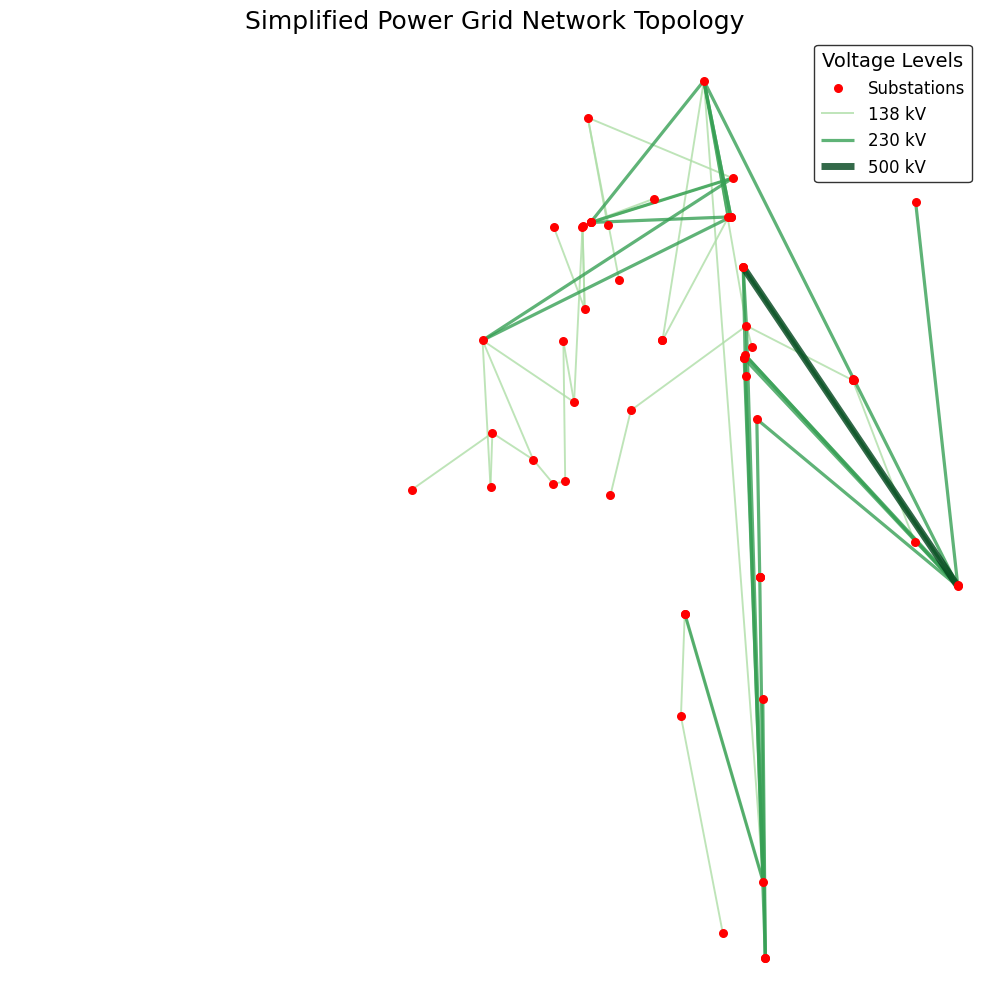

In [292]:
plt.figure(figsize=(10, 10))

valid_nodes = [n for n in G.nodes if n in pos]
nx.draw_networkx_nodes(
    G, pos, 
    nodelist=valid_nodes,
    node_size=30,
    node_color='red',
    label='Substations'
)

for volt in voltages:
    edgelist = [
        (u, v) for u, v, d in G.edges(data=True) 
        if d.get('VOLTAGE') == volt
    ]
    
    current_width = volt / 100
    print(current_width)
    if edgelist:
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=edgelist,
            width=current_width,
            edge_color=[voltage_colors[volt]],
            alpha=0.8,
            label=f"{int(volt)} kV"
        )
        # if current_width == 5.0:
        #     print(edgelist)

plt.title("Simplified Power Grid Network Topology", fontsize=18)
plt.axis('off')

plt.legend(
    loc='upper right', 
    title="Voltage Levels", 
    fontsize=12, 
    title_fontsize=14,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.xlim(global_xlim)
plt.ylim(global_ylim)

plt.tight_layout()
plt.show()

In [293]:
df_edges = nx.to_pandas_edgelist(G)
df_edges

,source,target,edge_type,VOLTAGE
0,ANDYTOWN,ORANGE RIVER,power_transmission,500.0
1,ORANGE RIVER,FORT MYERS SWITCHYARD,power_transmission,230.0
2,ORANGE RIVER,GATEWAY,power_transmission,230.0
3,ORANGE RIVER,TAP167094,power_transmission,230.0
4,ORANGE RIVER,ALVA,power_transmission,230.0
...,...,...,...,...
62,TAP155021,DEADEND167101,power_transmission,138.0
63,IMPERIAL,BONITA SPRINGS,power_transmission,138.0
64,COLONIAL,EDISON,power_transmission,138.0
65,TAP153225,TAP154083,power_transmission,138.0


### Connect plants to substations

Lines Bounds: 
[589607.9197 258950.1798 642397.3796 309123.9343]
Nodes Bounds: 
[620184.9426 293865.9384 622545.1954 301057.0563]


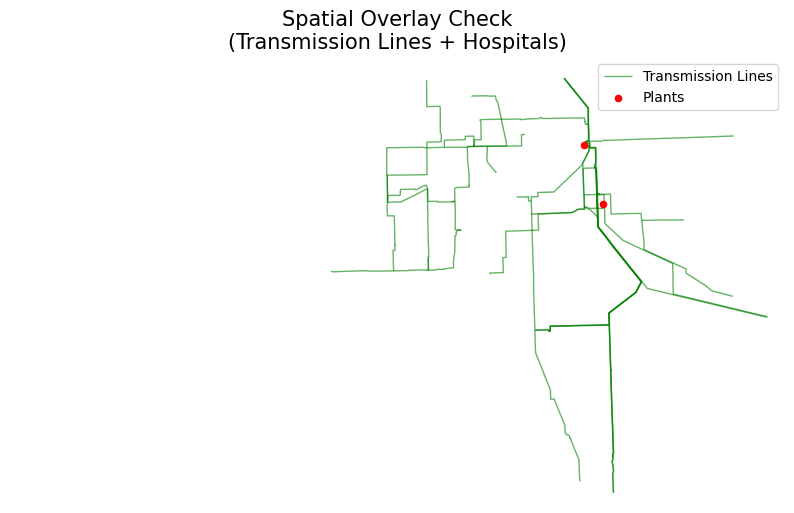

In [294]:
target_crs = 3087
lines_viz = valid_transmission.to_crs(epsg=target_crs)
nodes_viz = plants.to_crs(epsg=target_crs)

print(f"Lines Bounds: \n{lines_viz.total_bounds}")
print(f"Nodes Bounds: \n{nodes_viz.total_bounds}")

fig, ax = plt.subplots(figsize=(10, 10))

lines_viz.plot(
    ax=ax, 
    color='green', 
    linewidth=1, 
    alpha=0.6, 
    label='Transmission Lines'
)

nodes_viz.plot(
    ax=ax, 
    color='red', 
    marker='o',
    markersize=20, 
    label='Plants',
    zorder=5
)

plt.xlim(global_xlim)
plt.ylim(global_ylim)

plt.title("Spatial Overlay Check\n(Transmission Lines + Hospitals)", fontsize=15)
plt.legend()
plt.axis('off')
plt.show()

In [295]:
G_power = G.copy()
len(G_power.nodes)

57

In [296]:
plants

,SEQPLT,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,BANAME,BACODE,NERC,SUBRGN,SRNAME,ISORTO,FIPSST,FIPSCNTY,CNTYNAME,LAT,LON,CAMDFLAG,NUMUNT,NUMGEN,PLPRMFL,PLFUELCT,COALFLAG,CAPFAC,NAMEPCAP,NBFACTOR,RMBMFLAG,CHPFLAG,USETHRMO,PWRTOHT,ELCALLOC,PSFLAG,PLHTIAN,PLHTIOZ,PLHTIANT,PLHTIOZT,PLNGENAN,PLNGENOZ,PLNOXAN,PLNOXOZ,PLSO2AN,PLCO2AN,PLCH4AN,PLN2OAN,PLCO2EQA,PLHGAN,PLNOXRTA,PLNOXRTO,PLSO2RTA,PLCO2RTA,PLCH4RTA,PLN2ORTA,PLC2ERTA,PLHGRTA,PLNOXRA,PLNOXRO,PLSO2RA,PLCO2RA,PLCH4RA,PLN2ORA,PLC2ERA,PLHGRA,PLNOXCRT,PLNOXCRO,PLSO2CRT,PLCO2CRT,PLCH4CRT,PLN2OCRT,PLC2ECRT,PLHGCRT,UNNOX,UNNOXOZ,UNSO2,UNCO2,UNCH4,UNN2O,UNHG,UNHTI,UNHTIOZ,UNHTIT,UNHTIOZT,UNNOXSRC,UNNOZSRC,UNSO2SRC,UNCO2SRC,UNCH4SRC,UNN2OSRC,UNHGSRC,UNHTISRC,UNHOZSRC,BIONOX,BIONOXOZ,BIOSO2,BIOCO2,BIOCH4,BION2O,CHPCHTI,CHPCHTIOZ,CHPNOX,CHPNOXOZ,CHPSO2,CHPCO2,CHPCH4,CHPN2O,PLHTRT,PLGENACL,PLGENAOL,PLGENAGS,PLGENANC,PLGENAHY,PLGENABM,PLGENAWI,PLGENASO,PLGENAGT,PLGENAOF,PLGENAOP,PLGENATN,PLGENATR,PLGENATH,PLGENACY,PLGENACN,PLCLPR,PLOLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTHPR,PLCYPR,PLCNPR,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,OBJECTID_1,ID,CITY,STATE,ZIP,TYPE,STATUS,COUNTYFIPS,COUNTRY,LATITUDE,LONGITUDE,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,LINES,MAX_VOLT,MIN_VOLT,MAX_INFER,MIN_INFER,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
0,2548.0,2021.0,FL,Fort Myers,612.0,Florida Power & Light Co,6452.0,Florida Power & Light Co,6452.0,Electric Utility,Florida Power & Light Company,FPL,SERC,FRCC,FRCC All,,12,071,Lee,26.696700,-81.783100,Yes,10.0,14.0,NG,GAS,,0.41907,2680.9,0.634887,,,0.0,0.0,0.0,,6.932228e+07,3.314536e+07,6.932228e+07,3.314536e+07,9841677.0,4818740.0,963.061,463.215,23.370,4122017.181,157566.293,15832.609,4126345.818,,0.196,0.192,0.005,837.666,0.016,0.002,838.545,,0.028,0.028,0.001,118.923,0.002,0.000,119.048,,0.196,0.192,0.005,837.666,0.016,0.002,838.545,,963.061,463.215,23.370,4122017.181,157566.293,15832.609,,6.932228e+07,3.314536e+07,6.932228e+07,3.314536e+07,EPA/CAMD,EPA/CAMD,EPA/CAMD,EPA/CAMD,EIA,EIA,--,EPA/CAMD,EPA/CAMD,,,,,,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7043.746237,0.0,10193.222,9831483.78,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,9841677.002,0.00,0.00,9841677.002,0.0,0.0,0.001036,0.998964,0.0,0.0,0.0000,0.0,0.0,0.0,0.000000,0.0,1.0000,0.0000,0.0000,1.0,0.0,Fort Myers,0.0,Florida Power & Light Co,FloridaPowerPlantsFrom_eGRID_EPA_XY,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,ELC_PT_000064,,Lee,South Florida Water Management District,EPA,FloridaPowerPlantsFrom_eGRID_EPA_XY,,,,0,,,,,,,,,0.0,0.0,,,,1899-12-30 00:00:00+00:00,,1899-12-30 00:00:00+00:00,0.0,0.0,0.0,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Medium,Medium,High,High,High,High,High,Medium,Medium,Medium,Medium,Medium,Medium,POINT (620184.943 301057.056)
1,2593.0,2021.0,FL,Lee County Solid Waste Energy,52010.0,Florida Power & Light Co,6452.0,Lee County Board-Commissioners,10875.0,IPP Non-CHP,Florida Power & Light Company,FPL,SERC,FRCC,FRCC All,,12,071,Lee,26.631549,-81.760656,,3.0,2.0,MSW,BIOMASS,,0.63352,59.0,0.277468,Yes,,0.0,0.0,0.0,,5.764773e+06,2.538736e+06,5.764773e+06,2.538736e+06,327428.0,141203.0,604.995,278.614,49.747,317613.306,406674.966,53379.028,330650.218,,3.695,3.946,0.304,1940.050,1.242,0.163,2019.682,,0.210,0.219,0.017,110.191,0.071,0.009,114.714,,3.695,3.946,0.304,1940.050,1.242,0.163,2019.682,,604.995,278.614,49.747,576061.990,406674.966,53379.028,,5.764773e+06,2.538736e+0

In [297]:
# find the targets which can connect to the hospital
sub_candidates = valid_transmission[['SUB_2', 'geometry']].copy()
def get_endpoint(geom):
    if geom.geom_type == 'MultiLineString':
        return Point(geom.geoms[-1].coords[-1])
    else:
        return Point(geom.coords[-1])
    
sub_candidates['geometry'] = sub_candidates['geometry'].apply(get_endpoint)
sub_candidates

,SUB_2,geometry
52,ORANGE RIVER,POINT (642397.38 280188.543)
2,FORT MYERS SWITCHYARD,POINT (617846.557 309123.934)
40,CALUSA,POINT (606890.707 301013.868)
41,ORANGETREE,POINT (642394.633 280267.949)
17,FORT MYERS SWITCHYARD,POINT (620456.24 301334.677)
...,...,...
66,TAP151589,POINT (606890.707 301013.868)
63,TAP154083,POINT (638216.635 282731.775)
64,TAP153225,POINT (627200.433 291940.201)
77,TAP151589,POINT (613015.468 302303.048)


In [298]:
# drop duplicates
gdf_source = sub_candidates.drop_duplicates(subset=['SUB_2']).rename(columns={'SUB_2': 'source_id'})
gdf_source.shape

(36, 2)

In [299]:
# hospitals as targets
gdf_target = plants.copy()

# connect to the nearest substation
joined = gpd.sjoin_nearest(
    gdf_target,
    gdf_source,
    how='left',
    distance_col='dist'
)

joined

,SEQPLT,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,BANAME,BACODE,NERC,SUBRGN,SRNAME,ISORTO,FIPSST,FIPSCNTY,CNTYNAME,LAT,LON,CAMDFLAG,NUMUNT,NUMGEN,PLPRMFL,PLFUELCT,COALFLAG,CAPFAC,NAMEPCAP,NBFACTOR,RMBMFLAG,CHPFLAG,USETHRMO,PWRTOHT,ELCALLOC,PSFLAG,PLHTIAN,PLHTIOZ,PLHTIANT,PLHTIOZT,PLNGENAN,PLNGENOZ,PLNOXAN,PLNOXOZ,PLSO2AN,PLCO2AN,PLCH4AN,PLN2OAN,PLCO2EQA,PLHGAN,PLNOXRTA,PLNOXRTO,PLSO2RTA,PLCO2RTA,PLCH4RTA,PLN2ORTA,PLC2ERTA,PLHGRTA,PLNOXRA,PLNOXRO,PLSO2RA,PLCO2RA,PLCH4RA,PLN2ORA,PLC2ERA,PLHGRA,PLNOXCRT,PLNOXCRO,PLSO2CRT,PLCO2CRT,PLCH4CRT,PLN2OCRT,PLC2ECRT,PLHGCRT,UNNOX,UNNOXOZ,UNSO2,UNCO2,UNCH4,UNN2O,UNHG,UNHTI,UNHTIOZ,UNHTIT,UNHTIOZT,UNNOXSRC,UNNOZSRC,UNSO2SRC,UNCO2SRC,UNCH4SRC,UNN2OSRC,UNHGSRC,UNHTISRC,UNHOZSRC,BIONOX,BIONOXOZ,BIOSO2,BIOCO2,BIOCH4,BION2O,CHPCHTI,CHPCHTIOZ,CHPNOX,CHPNOXOZ,CHPSO2,CHPCO2,CHPCH4,CHPN2O,PLHTRT,PLGENACL,PLGENAOL,PLGENAGS,PLGENANC,PLGENAHY,PLGENABM,PLGENAWI,PLGENASO,PLGENAGT,PLGENAOF,PLGENAOP,PLGENATN,PLGENATR,PLGENATH,PLGENACY,PLGENACN,PLCLPR,PLOLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTHPR,PLCYPR,PLCNPR,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,OBJECTID_1,ID,CITY,STATE,ZIP,TYPE,STATUS,COUNTYFIPS,COUNTRY,LATITUDE,LONGITUDE,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,LINES,MAX_VOLT,MIN_VOLT,MAX_INFER,MIN_INFER,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry,index_right,source_id,dist
0,2548.0,2021.0,FL,Fort Myers,612.0,Florida Power & Light Co,6452.0,Florida Power & Light Co,6452.0,Electric Utility,Florida Power & Light Company,FPL,SERC,FRCC,FRCC All,,12,071,Lee,26.696700,-81.783100,Yes,10.0,14.0,NG,GAS,,0.41907,2680.9,0.634887,,,0.0,0.0,0.0,,6.932228e+07,3.314536e+07,6.932228e+07,3.314536e+07,9841677.0,4818740.0,963.061,463.215,23.370,4122017.181,157566.293,15832.609,4126345.818,,0.196,0.192,0.005,837.666,0.016,0.002,838.545,,0.028,0.028,0.001,118.923,0.002,0.000,119.048,,0.196,0.192,0.005,837.666,0.016,0.002,838.545,,963.061,463.215,23.370,4122017.181,157566.293,15832.609,,6.932228e+07,3.314536e+07,6.932228e+07,3.314536e+07,EPA/CAMD,EPA/CAMD,EPA/CAMD,EPA/CAMD,EIA,EIA,--,EPA/CAMD,EPA/CAMD,,,,,,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7043.746237,0.0,10193.222,9831483.78,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,9841677.002,0.00,0.00,9841677.002,0.0,0.0,0.001036,0.998964,0.0,0.0,0.0000,0.0,0.0,0.0,0.000000,0.0,1.0000,0.0000,0.0000,1.0,0.0,Fort Myers,0.0,Florida Power & Light Co,FloridaPowerPlantsFrom_eGRID_EPA_XY,,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,ELC_PT_000064,,Lee,South Florida Water Management District,EPA,FloridaPowerPlantsFrom_eGRID_EPA_XY,,,,0,,,,,,,,,0.0,0.0,,,,1899-12-30 00:00:00+00:00,,1899-12-30 00:00:00+00:00,0.0,0.0,0.0,,,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Medium,Medium,High,High,High,High,High,Medium,Medium,Medium,Medium,Medium,Medium,POINT (620184.943 301057.056),70,TAP167094,2994.280729
1,2593.0,2021.0,FL,Lee County Solid Waste Energy,52010.0,Florida Power & Light Co,6452.0,Lee County Board-Commissioners,10875.0,IPP Non-CHP,Florida Power & Light Company,FPL,SERC,FRCC,FRCC All,,12,071,Lee,26.631549,-81.760656,,3.0,2.0,MSW,BIOMASS,,0.63352,59.0,0.277468,Yes,,0.0,0.0,0.0,,5.764773e+06,2.538736e+06,5.764773e+06,2.538736e+06,327428.0,141203.0,604.995,278.614,49.747,317613.306,406674.966,53379.028,330650.218,,3.695,3.946,0.304,1940.050,1.242,0.163,2019.682,,0.210,0.219,0.017,110.191,0.071,0.009,114.714,,3.695,3.946,0.304,1940.050,1.242,0.163,2019.682,,604.995,278.614,49.747,57606

In [300]:
final_links = joined.sort_values('dist').drop_duplicates(subset=['PNAME'])

plant_power_df = pd.DataFrame({
    'source': final_links['PNAME'],   # Plants
    'target': final_links['source_id'], # Substations
    'VOLTAGE': 500.0,
    'edge_type': 'plant_power'
})

plant_power_df

,source,target,VOLTAGE,edge_type
1,Lee County Solid Waste Energy,TAP152014,500.0,plant_power
0,Fort Myers,TAP167094,500.0,plant_power


In [301]:
for idx, row in plants.iterrows():
    h_id = row['PNAME']
    geom = row.geometry.centroid if row.geometry.geom_type != 'Point' else row.geometry
    G.add_node(h_id, pos=(geom.x, geom.y), type='plants')
    pos[h_id] = (geom.x, geom.y)


count = 0
for idx, row in plant_power_df.iterrows():
    u = row['source'] # plants
    v = row['target'] # substations
    
    # Check if all the nodes are in G
    if u in G and v in G:
        G.add_edge(
            u, v, 
            VOLTAGE=row['VOLTAGE'],   # 138.0
            edge_type=row['edge_type'] # 'plant_power'
        )
        count += 1
    else:
        print(f"Warning: cannot connect {u} -> {v}")

print(f"Have added {count} edges")
print(f"Plant + Power network: {len(G.nodes)} nodes, {len(G.edges)} edges")

Have added 2 edges
Plant + Power network: 59 nodes, 69 edges


### Connect substations to hospitals

Lines Bounds: 
[589607.9197 258950.1798 642397.3796 309123.9343]
Nodes Bounds: 
[604469.657  279783.8271 613816.9998 294418.2952]


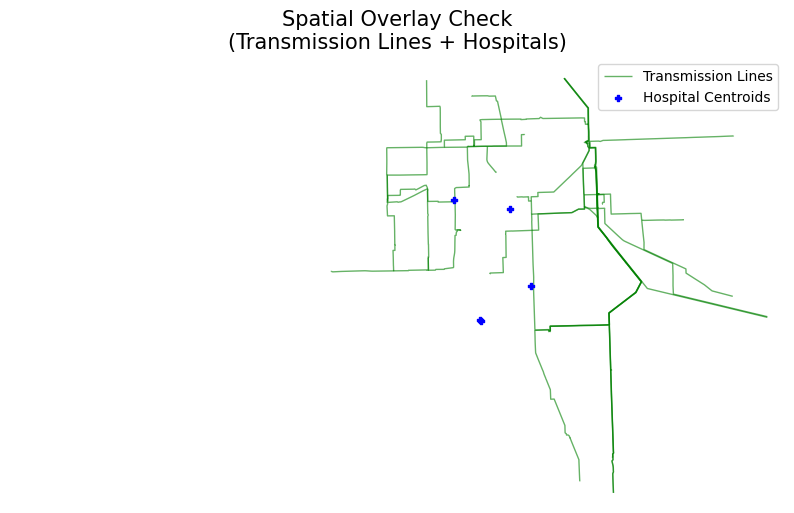

In [302]:
target_crs = 3087
lines_viz = valid_transmission.to_crs(epsg=target_crs)
nodes_viz = hospital.to_crs(epsg=target_crs)

print(f"Lines Bounds: \n{lines_viz.total_bounds}")
print(f"Nodes Bounds: \n{nodes_viz.total_bounds}")

fig, ax = plt.subplots(figsize=(10, 10))

lines_viz.plot(
    ax=ax, 
    color='green', 
    linewidth=1, 
    alpha=0.6, 
    label='Transmission Lines'
)

nodes_viz.plot(
    ax=ax, 
    color='blue', 
    marker='P',
    markersize=20, 
    label='Hospital Centroids',
    zorder=5
)

plt.xlim(global_xlim)
plt.ylim(global_ylim)

plt.title("Spatial Overlay Check\n(Transmission Lines + Hospitals)", fontsize=15)
plt.legend()
plt.axis('off')
plt.show()

In [303]:
G_power = G.copy()
len(G_power.nodes)

59

In [304]:
hospital

,BldgDataSo,FolioID,STRAP,ParcelBldg,BuildingKe,SubCondoNa,CondoBldgN,AddressNo,StreetName,AddressBld,StreetAddr,PostalCity,PostalCode,BldgUseTyp,BldgDescri,BasemapCla,Residentia,MaxStories,ActualArea,EffectiveA,ActualYear,EffectiveY,EstimatedV,ValueSourc,ModifyDate,ModifiedBy,GlobalID,created_us,created_da,last_edite,last_edi_1,ORIG_FID,geometry,Hospital_ID
0,LeePA Building Footprints,10221123,044624030000B0000,2,285149,HEALTHPARK FLORIDA WEST,,,,,,,,OFFICE/MEDICAL,Hospital,Medical,0,7.0,411299,352122,2017,2017,164282519.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,760cdc5b-b8bd-40f6-af01-0c06ab30fab6,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,1,POINT (607735.525 279783.827),Hosp_0
1,LeePA Building Footprints,10554317,19452528000000020,1,253199,GULF COAST MEDICAL CENTER,,13681,DOCTORS WAY,,13681 DOCTORS WAY,FORT MYERS,33912,OFFICE/MEDICAL,Hospital,Medical,1,4.0,741488,722427,1990,2006,220906618.0,Depreciated Value,2020-04-02 00:00:00+00:00,HOSKISSONB,fdcf759e-b575-4a3e-9c7a-4ec48bae2248,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,2,POINT (613817 283988.324),Hosp_1
2,LeePA Building Footprints,10221123,044624030000B0000,1,120200,HEALTHPARK FLORIDA WEST,,9981,SOUTH HEALTHPARK DR,,9981 SOUTH HEALTHPARK DR,FORT MYERS,33908,OFFICE/MEDICAL,Hospital,Medical,0,8.0,704752,659458,1991,2010,243928239.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,3617087f-8ca4-4a9b-b8c4-ef8d3ff4489a,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,3,POINT (607629.543 279809.163),Hosp_2
3,LeePA Building Footprints,10172610,234424P3020130010,1,89042,EDISON PARK,,2776,CLEVELAND AVE,,2776 CLEVELAND AVE,FORT MYERS,33901,OFFICE/MEDICAL,Hospital,Medical,0,8.0,326031,316145,1967,1990,78207950.0,Depreciated Value,2019-07-10 00:00:00+00:00,HOSKISSONB,67458aaa-d3f5-4988-b392-4a28bc659938,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,4,POINT (611286.048 293324.612),Hosp_3
4,LeePA Building Footprints,10167861,184424C3000020000,1,85868,CAPE CORAL UNIT 1824,,636,DEL PRADO BLVD S,,636 DEL PRADO BLVD S,CAPE CORAL,33990,OFFICE/MEDICAL,Hospital,Medical,0,5.0,513489,494850,1976,1997,114040162.0,Depreciated Value,2025-01-07 00:00:00+00:00,HOSKISSONB,afd68383-59d2-47be-9ff0-adaaf9c7dfee,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,5,POINT (604469.657 294418.295),Hosp_4


In [305]:
# find the targets which can connect to the hospital
sub_candidates = valid_transmission[['SUB_2', 'geometry']].copy()
def get_endpoint(geom):
    if geom.geom_type == 'MultiLineString':
        return Point(geom.geoms[-1].coords[-1])
    else:
        return Point(geom.coords[-1])
    
sub_candidates['geometry'] = sub_candidates['geometry'].apply(get_endpoint)
sub_candidates

,SUB_2,geometry
52,ORANGE RIVER,POINT (642397.38 280188.543)
2,FORT MYERS SWITCHYARD,POINT (617846.557 309123.934)
40,CALUSA,POINT (606890.707 301013.868)
41,ORANGETREE,POINT (642394.633 280267.949)
17,FORT MYERS SWITCHYARD,POINT (620456.24 301334.677)
...,...,...
66,TAP151589,POINT (606890.707 301013.868)
63,TAP154083,POINT (638216.635 282731.775)
64,TAP153225,POINT (627200.433 291940.201)
77,TAP151589,POINT (613015.468 302303.048)


In [306]:
# drop duplicates
gdf_source = sub_candidates.drop_duplicates(subset=['SUB_2']).rename(columns={'SUB_2': 'source_id'})
gdf_source.shape

(36, 2)

In [307]:
# hospitals as targets
gdf_target = hospital.copy()

# connect to the nearest substation
joined = gpd.sjoin_nearest(
    gdf_target,
    gdf_source,
    how='left',
    distance_col='dist'
)

joined

,BldgDataSo,FolioID,STRAP,ParcelBldg,BuildingKe,SubCondoNa,CondoBldgN,AddressNo,StreetName,AddressBld,StreetAddr,PostalCity,PostalCode,BldgUseTyp,BldgDescri,BasemapCla,Residentia,MaxStories,ActualArea,EffectiveA,ActualYear,EffectiveY,EstimatedV,ValueSourc,ModifyDate,ModifiedBy,GlobalID,created_us,created_da,last_edite,last_edi_1,ORIG_FID,geometry,Hospital_ID,index_right,source_id,dist
0,LeePA Building Footprints,10221123,044624030000B0000,2,285149,HEALTHPARK FLORIDA WEST,,,,,,,,OFFICE/MEDICAL,Hospital,Medical,0,7.0,411299,352122,2017,2017,164282519.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,760cdc5b-b8bd-40f6-af01-0c06ab30fab6,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,1,POINT (607735.525 279783.827),Hosp_0,69,EDISON,5743.325733
1,LeePA Building Footprints,10554317,19452528000000020,1,253199,GULF COAST MEDICAL CENTER,,13681,DOCTORS WAY,,13681 DOCTORS WAY,FORT MYERS,33912,OFFICE/MEDICAL,Hospital,Medical,1,4.0,741488,722427,1990,2006,220906618.0,Depreciated Value,2020-04-02 00:00:00+00:00,HOSKISSONB,fdcf759e-b575-4a3e-9c7a-4ec48bae2248,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,2,POINT (613817 283988.324),Hosp_1,69,EDISON,5201.041102
2,LeePA Building Footprints,10221123,044624030000B0000,1,120200,HEALTHPARK FLORIDA WEST,,9981,SOUTH HEALTHPARK DR,,9981 SOUTH HEALTHPARK DR,FORT MYERS,33908,OFFICE/MEDICAL,Hospital,Medical,0,8.0,704752,659458,1991,2010,243928239.0,Depreciated Value,2017-10-27 00:00:00+00:00,HOSKISSONB,3617087f-8ca4-4a9b-b8c4-ef8d3ff4489a,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,3,POINT (607629.543 279809.163),Hosp_2,69,EDISON,5739.453401
3,LeePA Building Footprints,10172610,234424P3020130010,1,89042,EDISON PARK,,2776,CLEVELAND AVE,,2776 CLEVELAND AVE,FORT MYERS,33901,OFFICE/MEDICAL,Hospital,Medical,0,8.0,326031,316145,1967,1990,78207950.0,Depreciated Value,2019-07-10 00:00:00+00:00,HOSKISSONB,67458aaa-d3f5-4988-b392-4a28bc659938,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,4,POINT (611286.048 293324.612),Hosp_3,1,TAP151595,2727.432553
4,LeePA Building Footprints,10167861,184424C3000020000,1,85868,CAPE CORAL UNIT 1824,,636,DEL PRADO BLVD S,,636 DEL PRADO BLVD S,CAPE CORAL,33990,OFFICE/MEDICAL,Hospital,Medical,0,5.0,513489,494850,1976,1997,114040162.0,Depreciated Value,2025-01-07 00:00:00+00:00,HOSKISSONB,afd68383-59d2-47be-9ff0-adaaf9c7dfee,LCGIS,2025-11-18 00:00:00+00:00,LCGIS,2025-11-19 00:00:00+00:00,5,POINT (604469.657 294418.295),Hosp_4,45,TROPIC ISLE,286.333020


In [308]:
final_links = joined.sort_values('dist').drop_duplicates(subset=['Hospital_ID'])

hospital_access_df = pd.DataFrame({
    'source': final_links['source_id'],   # Substations
    'target': final_links['Hospital_ID'], # Hospitals
    'VOLTAGE': 138.0,
    'edge_type': 'power_hospital'
})

hospital_access_df

,source,target,VOLTAGE,edge_type
4,TROPIC ISLE,Hosp_4,138.0,power_hospital
3,TAP151595,Hosp_3,138.0,power_hospital
1,EDISON,Hosp_1,138.0,power_hospital
2,EDISON,Hosp_2,138.0,power_hospital
0,EDISON,Hosp_0,138.0,power_hospital


In [309]:
for idx, row in hospital.iterrows():
    h_id = row['Hospital_ID']
    geom = row.geometry.centroid if row.geometry.geom_type != 'Point' else row.geometry
    G.add_node(h_id, pos=(geom.x, geom.y), type='hospitals')
    pos[h_id] = (geom.x, geom.y)


count = 0
for idx, row in hospital_access_df.iterrows():
    u = row['source'] # substation
    v = row['target'] # Hospital
    
    # Check if all the nodes are in G
    if u in G and v in G:
        G.add_edge(
            u, v, 
            VOLTAGE=row['VOLTAGE'],   # 138.0
            edge_type=row['edge_type'] # 'hospital_access'
        )
        count += 1
    else:
        print(f"Warning: cannot connect {u} -> {v}")

print(f"Have added {count} edges")
print(f"Hospital + Power network: {len(G.nodes)} nodes, {len(G.edges)} edges")

Have added 5 edges
Hospital + Power network: 64 nodes, 74 edges


['Fort Myers', 'Lee County Solid Waste Energy']


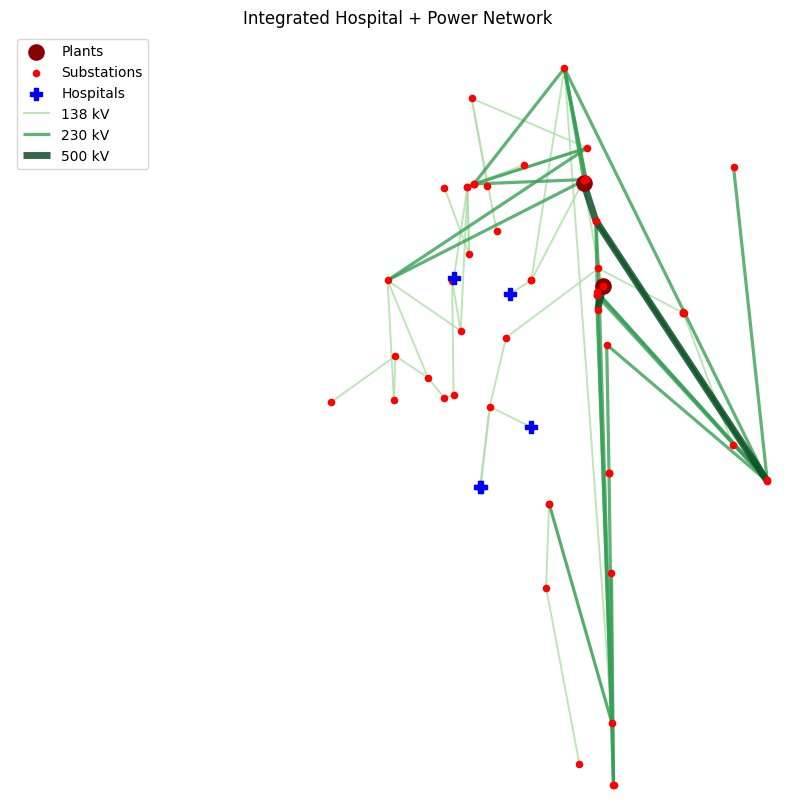

In [310]:
plt.figure(figsize=(10, 10))

# Plants
plant_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'plants']
nx.draw_networkx_nodes(G, pos, nodelist=plant_nodes, node_size=120, node_color='darkred', label='Plants')
print(plant_nodes)

# Substations
sub_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'substations']
sub_nodes = [n for n in sub_nodes if n in pos]
nx.draw_networkx_nodes(G, pos, nodelist=sub_nodes, node_size=20, node_color='red', label='Substations')

# Hospitals
hosp_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'hospitals']
nx.draw_networkx_nodes(G, pos, nodelist=hosp_nodes, node_size=80, node_color='blue', node_shape='P', label='Hospitals')

# Edges
for volt in voltages:
    edgelist = [
        (u, v) for u, v, d in G.edges(data=True) 
        if d.get('VOLTAGE') == volt
    ]
    
    current_width = volt / 100
    if edgelist:
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=edgelist,
            width=current_width,
            edge_color=[voltage_colors[volt]],
            alpha=0.8,
            label=f"{int(volt)} kV"
        )

plt.xlim(global_xlim)
plt.ylim(global_ylim)

plt.legend()
plt.title("Integrated Hospital + Power Network")
plt.axis('off')
plt.show()

In [311]:
node_data = dict(G.nodes(data=True))
df_nodes = pd.DataFrame.from_dict(node_data, orient='index')
df_nodes = df_nodes.reset_index().rename(columns={'index': 'Node_ID'})
df_nodes

,Node_ID,type,pos
0,ANDYTOWN,substations,"(621650.9567999989, 298446.2098000003)"
1,ORANGE RIVER,substations,"(621846.0711000003, 293422.78780000005)"
2,HERCULES,substations,"(620456.2397999987, 301334.6765999999)"
3,FORT MYERS SWITCHYARD,substations,"(613844.7604999989, 294269.00409999955)"
4,LEE,substations,"(613015.4679999985, 302303.0480000004)"
...,...,...,...
59,Hosp_0,hospitals,"(607735.5247999988, 279783.82710000034)"
60,Hosp_1,hospitals,"(613816.9998000003, 283988.32430000044)"
61,Hosp_2,hospitals,"(607629.5432000011, 279809.1626000004)"
62,Hosp_3,hospitals,"(611286.0476000011, 293324.6118999999)"


In [312]:
df_edges = nx.to_pandas_edgelist(G)
df_edges

,source,target,edge_type,VOLTAGE
0,ANDYTOWN,ORANGE RIVER,power_transmission,500.0
1,ORANGE RIVER,FORT MYERS SWITCHYARD,power_transmission,230.0
2,ORANGE RIVER,GATEWAY,power_transmission,230.0
3,ORANGE RIVER,TAP167094,power_transmission,230.0
4,ORANGE RIVER,ALVA,power_transmission,230.0
...,...,...,...,...
69,TAP153225,TAP154083,power_transmission,138.0
70,EDISON,Hosp_1,power_hospital,138.0
71,EDISON,Hosp_2,power_hospital,138.0
72,EDISON,Hosp_0,power_hospital,138.0


In [313]:
print(f"Hospital + Power network: {len(G.nodes)} nodes, {len(G.edges)} edges")

Hospital + Power network: 64 nodes, 74 edges


In [314]:
target_node = 'Hosp_0'
for source, target, attributes in G.edges(target_node, data=True):
    print(f"Target: {target}")
    print(f"Attributes: {attributes}")

Target: EDISON
Attributes: {'VOLTAGE': 138.0, 'edge_type': 'power_hospital'}


In [315]:
target_node = 'EDISON'
for source, target, attributes in G.edges(target_node, data=True):
    print(f"Target: {target}")
    print(f"Attributes: {attributes}")

Target: COLONIAL
Attributes: {'VOLTAGE': 138.0, 'edge_type': 'power_transmission'}
Target: Hosp_1
Attributes: {'VOLTAGE': 138.0, 'edge_type': 'power_hospital'}
Target: Hosp_2
Attributes: {'VOLTAGE': 138.0, 'edge_type': 'power_hospital'}
Target: Hosp_0
Attributes: {'VOLTAGE': 138.0, 'edge_type': 'power_hospital'}


## Communication

In [316]:
comm = gpd.read_file(gdb_path, layer='Lee_Communication_Tower')
print(comm.shape)
comm.head(5)

(205, 78)


,OBJECTID_1,Permanent_,Source_Fea,Source_Dat,Source_D_1,Source_Ori,Data_Secur,Distributi,LoadDate,FType,FCode,Name,IsLandmark,PointLocat,AdminType,AddressBui,Address,City,State,Zipcode,GNIS_ID,Foot_ID,Complex_ID,OBJECTID__,Ftype_jn,Fcode_jn,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Zip,X,Y,LONGLAT,USNG,OWNERSHIP,PARCELID,FACILITY_T,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
0,1,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,REYES TREE FARM INC - Verizon Wireless,0,0,0,,8550 NALLE GRADE RD,NORTH FORT MYERS,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_000780,,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,33917,-81.816521,26.753162,"-81.81652112,26.75316168",17R MK 18810 59356,,,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (616754.888 307264.992)
1,3,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,LEHIGH ACRES JAYCEES INC,0,0,0,,500 SUNSHINE BLVD N,500 SUNSHINE BLVD N,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_000782,,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,,-81.683479,26.618303,"-81.68347865,26.61830298",17R MK 31960 44341,,,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,77,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (630241.787 292537.431)
2,4,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,LEE COUNTY,0,0,0,,11831 BAYSHORE RD,NORTH FORT MYERS,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_000783,,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,33917,-81.763910,26.724133,"-81.76391043,26.72413262",17R MK 24023 56108,,,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,76,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,High,High,High,High,High,High,High,High,High,High,Medium,Medium,Medium,Medium,Medium,Medium,POINT (622035.444 304136.405)
3,5,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,FIBERTOWER NETWORK SERVICES CORP.,0,0,0,,2437 SW PINE ISLAND RD,CAPE CORAL,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_000784,Cape Coral,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,33991,-82.025300,26.640300,"-82.02530000,26.64030000",17R LK 97949 47005,,,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,79,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Low,Medium,Medium,Medium,High,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (596231.813 294387.889)
4,7,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,CAPITAL TELECOM,0,0,0,,11941 BONITA BEACH RD SE,Bonita Springs,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_000786,Bonita Springs,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,34135,-81.756100,26

In [317]:
comm.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [318]:
G_power_hosp = G.copy()
len(G_power_hosp.nodes)

64

In [319]:
comm['Comm_ID'] = 'Comm_' + comm.index.astype(str)
print(f"The number of towers: {len(comm)}")

The number of towers: 205


### Connect towers to hospitals (<3 km)

In [320]:
radius_meters = 3000
hosp_buffer = hospital.copy()
hosp_buffer['geometry'] = hosp_buffer.geometry.buffer(radius_meters)
comm_links = gpd.sjoin(
    comm, 
    hosp_buffer[['geometry', 'Hospital_ID']], 
    how='inner', 
    predicate='within'
)

print(f"Have found {len(comm_links)} communication edges within 1 mile")

Have found 48 communication edges within 1 mile


In [321]:
comm_links.head(2)

,OBJECTID_1,Permanent_,Source_Fea,Source_Dat,Source_D_1,Source_Ori,Data_Secur,Distributi,LoadDate,FType,FCode,Name,IsLandmark,PointLocat,AdminType,AddressBui,Address,City,State,Zipcode,GNIS_ID,Foot_ID,Complex_ID,OBJECTID__,Ftype_jn,Fcode_jn,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Zip,X,Y,LONGLAT,USNG,OWNERSHIP,PARCELID,FACILITY_T,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry,Comm_ID,index_right,Hospital_ID
17,2663,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,FORT MYERS BROADCASTING COMPANY,0,0,0,,12381 CLEVELAND AVE,FORT MYERS,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_003442,,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,33907,-81.871500,26.562600,"-81.87150000,26.56260000",17R MK 13199 38285,,,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (611662.788 286018.028),Comm_17,1,Hosp_1
24,2670,,,,,,0,,1899-12-30 00:00:00+00:00,0,0,FORT MYERS FL MAIN HOST CO/OFC,0,0,0,,1520 LEE ST,FORT MYERS,,,,,,0.0,,,0.0,,Communications - FDEM,,Communications Facilities,Critical infrastructure,Locally Significant,COM_003449,Fort Myers,Lee,South Florida Water Management District,FDEM,Communications - FDEM,,,,33901,-81.868139,26.644551,"-81.86813945,26.64455089",17R MK 13596 47360,,,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Medium,Medium,High,High,High,High,High,Low,Not Affected,Low,Low,Low,Low,POINT (611839.669 295119.759),Comm_24,3,Hosp_3


In [322]:
hospital_comm_df = pd.DataFrame({
    'source': comm_links['Comm_ID'],   # Substations
    'target': comm_links['Hospital_ID'], # Hospitals
    'edge_type': 'comm_hospital'
})

print(hospital_comm_df.shape)
hospital_comm_df

(48, 3)


,source,target,edge_type
17,Comm_17,Hosp_1,comm_hospital
24,Comm_24,Hosp_3,comm_hospital
32,Comm_32,Hosp_3,comm_hospital
40,Comm_40,Hosp_0,comm_hospital
40,Comm_40,Hosp_2,comm_hospital
46,Comm_46,Hosp_0,comm_hospital
46,Comm_46,Hosp_2,comm_hospital
48,Comm_48,Hosp_3,comm_hospital
52,Comm_52,Hosp_3,comm_hospital
55,Comm_55,Hosp_4,comm_hospital


In [323]:
G = G_power_hosp.copy()
df_edges = nx.to_pandas_edgelist(G)
df_edges

,source,target,edge_type,VOLTAGE
0,ANDYTOWN,ORANGE RIVER,power_transmission,500.0
1,ORANGE RIVER,FORT MYERS SWITCHYARD,power_transmission,230.0
2,ORANGE RIVER,GATEWAY,power_transmission,230.0
3,ORANGE RIVER,TAP167094,power_transmission,230.0
4,ORANGE RIVER,ALVA,power_transmission,230.0
...,...,...,...,...
69,TAP153225,TAP154083,power_transmission,138.0
70,EDISON,Hosp_1,power_hospital,138.0
71,EDISON,Hosp_2,power_hospital,138.0
72,EDISON,Hosp_0,power_hospital,138.0


In [324]:
for idx, row in comm_links.iterrows():
    c_id = row['Comm_ID']
    geom = row.geometry
    
    G.add_node(
        c_id, 
        pos=(geom.x, geom.y), 
        type='communication'
    )
    pos[c_id] = (geom.x, geom.y)

count = 0
for idx, row in hospital_comm_df.iterrows():
    u = row['source']
    v = row['target']

    G.add_edge(
        u, v, 
        edge_type='comm_hospital'
    )
    count += 1

print(f"Have added {hospital_comm_df} edges")
print(f"Hospital + Power + Comm network: {len(G.nodes)} nodes, {len(G.edges)} edges")


Have added        source  target      edge_type
17    Comm_17  Hosp_1  comm_hospital
24    Comm_24  Hosp_3  comm_hospital
32    Comm_32  Hosp_3  comm_hospital
40    Comm_40  Hosp_0  comm_hospital
40    Comm_40  Hosp_2  comm_hospital
46    Comm_46  Hosp_0  comm_hospital
46    Comm_46  Hosp_2  comm_hospital
48    Comm_48  Hosp_3  comm_hospital
52    Comm_52  Hosp_3  comm_hospital
55    Comm_55  Hosp_4  comm_hospital
66    Comm_66  Hosp_3  comm_hospital
72    Comm_72  Hosp_1  comm_hospital
83    Comm_83  Hosp_3  comm_hospital
87    Comm_87  Hosp_0  comm_hospital
87    Comm_87  Hosp_2  comm_hospital
91    Comm_91  Hosp_0  comm_hospital
91    Comm_91  Hosp_2  comm_hospital
93    Comm_93  Hosp_1  comm_hospital
94    Comm_94  Hosp_1  comm_hospital
98    Comm_98  Hosp_3  comm_hospital
100  Comm_100  Hosp_4  comm_hospital
115  Comm_115  Hosp_0  comm_hospital
115  Comm_115  Hosp_2  comm_hospital
117  Comm_117  Hosp_4  comm_hospital
118  Comm_118  Hosp_1  comm_hospital
122  Comm_122  Hosp_3  comm

In [325]:
df_edges = nx.to_pandas_edgelist(G)
df_edges

,source,target,edge_type,VOLTAGE
0,ANDYTOWN,ORANGE RIVER,power_transmission,500.0
1,ORANGE RIVER,FORT MYERS SWITCHYARD,power_transmission,230.0
2,ORANGE RIVER,GATEWAY,power_transmission,230.0
3,ORANGE RIVER,TAP167094,power_transmission,230.0
4,ORANGE RIVER,ALVA,power_transmission,230.0
...,...,...,...,...
117,Hosp_4,Comm_100,comm_hospital,NaN
118,Hosp_4,Comm_117,comm_hospital,NaN
119,Hosp_4,Comm_129,comm_hospital,NaN
120,Hosp_4,Comm_180,comm_hospital,NaN


['Fort Myers', 'Lee County Solid Waste Energy']


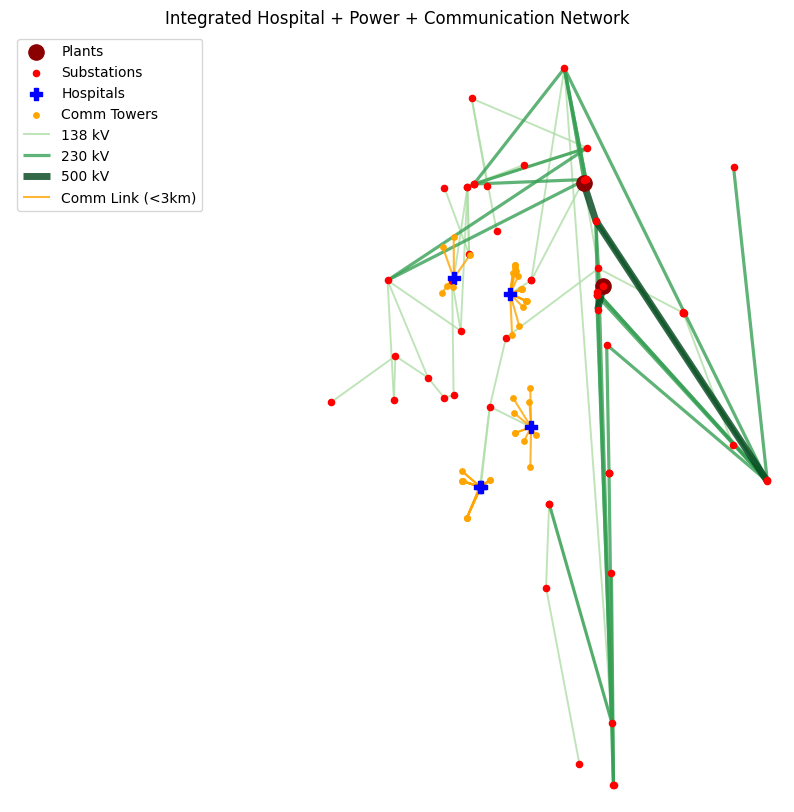

In [326]:
plt.figure(figsize=(10, 10))

# Plants
plant_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'plants']
nx.draw_networkx_nodes(G, pos, nodelist=plant_nodes, node_size=120, node_color='darkred', label='Plants')
print(plant_nodes)

# Substations
sub_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'substations']
sub_nodes = [n for n in sub_nodes if n in pos]
nx.draw_networkx_nodes(G, pos, nodelist=sub_nodes, node_size=20, node_color='red', label='Substations')

# Hospitals
hosp_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'hospitals']
nx.draw_networkx_nodes(G, pos, nodelist=hosp_nodes, node_size=80, node_color='blue', node_shape='P', label='Hospitals')

# Communication powers
comm_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'communication']

# Draw connected nodes
connected_comm = [n for n in comm_nodes if G.degree(n) > 0]
nx.draw_networkx_nodes(G, pos, nodelist=connected_comm, node_size=15, node_color='orange', label='Comm Towers')

# Edges
for volt in voltages:
    edgelist = [
        (u, v) for u, v, d in G.edges(data=True) 
        if d.get('VOLTAGE') == volt
    ]
    
    current_width = volt / 100
    if edgelist:
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=edgelist,
            width=current_width,
            edge_color=[voltage_colors[volt]],
            alpha=0.8,
            label=f"{int(volt)} kV"
        )

comm_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'comm_hospital']
if comm_edges:
    nx.draw_networkx_edges(G, pos, edgelist=comm_edges,edge_color='orange', alpha=0.8, width=1.5, label='Comm Link (<3km)')

plt.xlim(global_xlim)
plt.ylim(global_ylim)

plt.legend()
plt.title("Integrated Hospital + Power + Communication Network")
plt.axis('off')
plt.show()

In [327]:
node_data = dict(G.nodes(data=True))
df_nodes = pd.DataFrame.from_dict(node_data, orient='index')
df_nodes = df_nodes.reset_index().rename(columns={'index': 'Node_ID'})
df_nodes

,Node_ID,type,pos
0,ANDYTOWN,substations,"(621650.9567999989, 298446.2098000003)"
1,ORANGE RIVER,substations,"(621846.0711000003, 293422.78780000005)"
2,HERCULES,substations,"(620456.2397999987, 301334.6765999999)"
3,FORT MYERS SWITCHYARD,substations,"(613844.7604999989, 294269.00409999955)"
4,LEE,substations,"(613015.4679999985, 302303.0480000004)"
...,...,...,...
98,Comm_181,communication,"(605414.1319000013, 280227.46920000017)"
99,Comm_185,communication,"(603655.3198999986, 293844.2737999996)"
100,Comm_191,communication,"(606054.6224999987, 277640.36429999955)"
101,Comm_193,communication,"(605414.1319000013, 280227.46920000017)"


In [328]:
df_edges = nx.to_pandas_edgelist(G)
df_edges

,source,target,edge_type,VOLTAGE
0,ANDYTOWN,ORANGE RIVER,power_transmission,500.0
1,ORANGE RIVER,FORT MYERS SWITCHYARD,power_transmission,230.0
2,ORANGE RIVER,GATEWAY,power_transmission,230.0
3,ORANGE RIVER,TAP167094,power_transmission,230.0
4,ORANGE RIVER,ALVA,power_transmission,230.0
...,...,...,...,...
117,Hosp_4,Comm_100,comm_hospital,NaN
118,Hosp_4,Comm_117,comm_hospital,NaN
119,Hosp_4,Comm_129,comm_hospital,NaN
120,Hosp_4,Comm_180,comm_hospital,NaN


# Topological structure of networks

## Network sumamry (baseline/system-level)

- **Numbers of Nodes and Edges**:
    - **Number of nodes**:
    $$
    N = |V|
    $$

    - **Number of edges**:
    $$
    M = |E|
    $$

- **Network Density**: Network density measures the fraction of realized edges relative to all
possible edges.

    - **Undirected graph**:
    $$
    \rho = \frac{2M}{N(N-1)}
    $$

    - **Directed graph**:
    $$
    \rho = \frac{M}{N(N-1)}
    $$

- **Connected Components**: A connected component is a maximal set of nodes for which a path exists between all node pairs.

    - For **undirected graphs**, standard connected components are used.
    - For **directed graphs**, weakly connected components* are used, where edge
    direction is ignored.

- **Giant Connected Component (GCC)**: The **Giant Connected Component (GCC)** is the largest connected component in the network.

    - **GCC fraction**: This metric indicates the overall connectivity and integrity of the system.
    $$
    \text{GCC}_{\text{frac}} = \frac{|V_{\text{GCC}}|}{N}
    $$


- **Degree-Based Metrics**:
The degree $ k_i $ of node $ i $ is the number of edges incident to it.

    - **Average degree**:
    $$
    \langle k \rangle = \frac{1}{N} \sum_{i=1}^{N} k_i
    $$

    - **Maximum degree**:
    $$
    k_{\max} = \max_i k_i
    $$

- **Shortest-Path Metrics (Computed on GCC)**: Shortest-path-based metrics are computed on the GCC to avoid undefined distances between disconnected node pairs. (Range: $ 0≤E≤1$, $E=1$ means every node connected to every other node. Infrastructure networks ususally have low values.)

    - **Average shortest path length**:
    $$
    L = \frac{1}{|V_{\text{GCC}}|(|V_{\text{GCC}}|-1)}
    \sum_{i \neq j \in V_{\text{GCC}}} d(i,j)
    $$

    - **Network diameter**:
    $$
    D = \max_{i,j \in V_{\text{GCC}}} d(i,j)
    $$

    where $ d(i,j) $ denotes the shortest-path distance between nodes $ i $ and $ j $.

- **Global Efficiency**: Global efficiency measures how efficiently information or resources can be exchanged over the network, even when the graph is disconnected. Pairs of nodes that are not connected contribute zero to the sum. 

$$
E = \frac{1}{N(N-1)} \sum_{i \neq j} \frac{1}{d(i,j)}
$$

- **Clustering Coefficient**:
The local clustering coefficient $ C_i $ measures the tendency of a node’s neighbors to be connected. Let node $ i $ have: degree $k_i$ and neighbor set $N(i)$. Let $e_i$ = number of edges between nodes in $N(i)$.
    - **Local clustering coefficient**:
    $$
    C_i ​= \frac{2e_i}{k_i​(k_i​−1)} (k_i ​≥ 2)
    $$
    if $ k_i < 2$, define:
    $$
    C_i = 0
    $$

    - **Average clustering coefficient**:
    $$
    \bar{C} = \frac{1}{N} \sum_{i=1}^{N} C_i
    $$


In [329]:
len(list(nx.isolates(G)))

0

In [330]:
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
sizes[:10]

[103]

In [340]:
def summarize_graph(G, name="Integrated"):
    is_directed = G.is_directed()
    N, M = G.number_of_nodes(), G.number_of_edges()
    density = nx.density(G)

    if is_directed:
        print("is directed")
        comps = list(nx.weakly_connected_components(G)) # Returns the number of weakly connected components in G.
        GCC = max(comps, key=len)
        G_gcc = G.subgraph(GCC).copy()
    else:
        print("is not directed")
        comps = list(nx.connected_components(G)) # The number of connected components.
        GCC = max(comps, key=len)
        G_gcc = G.subgraph(GCC).copy()

    gcc_frac = len(GCC) / N if N else np.nan

    # path metrics on GCC (avoid errors if tiny)
    if G_gcc.number_of_nodes() >= 2 and nx.is_connected(G_gcc.to_undirected()):
        avg_path = nx.average_shortest_path_length(G_gcc.to_undirected())
        diam = nx.diameter(G_gcc.to_undirected())
    else:
        avg_path, diam = np.nan, np.nan

    eff = nx.global_efficiency(G.to_undirected())

    deg = np.array([d for _, d in G.degree()])
    return {
        "name": name,
        "N_nodes": N,
        "M_edges": M,
        "density": density,
        "n_components": len(comps),
        "gcc_frac": gcc_frac,
        "avg_degree": deg.mean() if N else np.nan,
        "max_degree": deg.max() if N else np.nan,
        "avg_path_len_GCC": avg_path,
        "diameter_GCC": diam,
        "global_efficiency": eff,
        "avg_clustering": nx.average_clustering(G.to_undirected())
    }

summary_df = pd.DataFrame([summarize_graph(G)])
summary_df

# Optional exports:
# summary_df.to_csv("network_summary.csv", index=False)
# print(summary_df.to_latex(index=False))

is not directed


,name,N_nodes,M_edges,density,n_components,gcc_frac,avg_degree,max_degree,avg_path_len_GCC,diameter_GCC,global_efficiency,avg_clustering
0,Integrated,103,122,0.023225,1,1.0,2.368932,16,5.960975,11,0.217355,0.03405


## Ranked critical nodes/edges

- **Node Betweenness Centrality**: measures how frequently a node lies on shortest paths between other node pairs.
- **Edge Betweenness Centrality**: measures how frequently an edge lies on shortest paths between node pairs.
- **Node Closeness Centrality**: measures how close a node is to all other nodes in terms of shortest-path distances.
- **PageRank Centrality**: calculates a node's importance based on the quantity and quality of incoming links.

In [332]:
# Node metrics
deg = dict(G.degree())
bet = nx.betweenness_centrality(G, normalized=True)
clo = nx.closeness_centrality(G)
pr  = nx.pagerank(G)

node_rows = []
for n in G.nodes():
    node_rows.append({
        "node": n,
        "type": G.nodes[n].get("type", None),
        "degree": deg.get(n, 0),
        "betweenness": bet.get(n, 0.0),
        "closeness": clo.get(n, 0.0),
        "pagerank": pr.get(n, 0.0),
    })
nodes_df = pd.DataFrame(node_rows)

print("\nTop-10 by betweenness:")
print(nodes_df.sort_values("betweenness", ascending=False).head(10).to_string(index=False))

# Edge metrics
eb = nx.edge_betweenness_centrality(G, normalized=True)
edges_df = pd.DataFrame([
    {"u": u, "v": v, "etype": G.edges[u, v].get("edge_type", None), "edge_betweenness": val}
    for (u, v), val in eb.items()
])
print("\nTop-10 edges by edge betweenness:")
print(edges_df.sort_values("edge_betweenness", ascending=False).head(10).to_string(index=False))

# Optional exports
# nodes_df.to_csv("node_metrics.csv", index=False)
# edges_df.to_csv("edge_metrics.csv", index=False)



Top-10 by betweenness:
                 node        type  degree  betweenness  closeness  pagerank
FORT MYERS SWITCHYARD substations       8     0.659289   0.284123  0.026452
           BUCKINGHAM substations       6     0.467676   0.265625  0.021075
               EDISON substations       4     0.351602   0.204000  0.013013
             COLONIAL substations       2     0.341681   0.231293  0.007207
            TAP151595 substations       4     0.283634   0.240000  0.015294
               Hosp_3   hospitals      16     0.273733   0.205645  0.072128
           CAPE NORTH substations       5     0.263962   0.219828  0.016985
            CHARLOTTE substations       3     0.245616   0.245783  0.010018
         ORANGE RIVER substations       7     0.212580   0.238876  0.025778
               Hosp_1   hospitals      10     0.169482   0.174957  0.043920

Top-10 edges by edge betweenness:
                    u                     v              etype  edge_betweenness
           BUCKINGHAM   

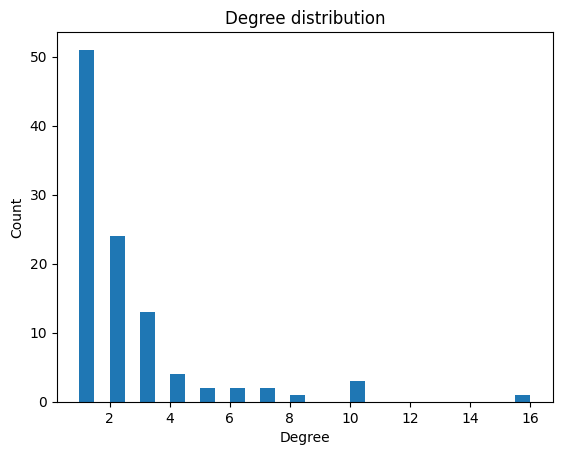

In [333]:
degrees = [d for _, d in G.degree()]
plt.figure()
plt.hist(degrees, bins=30)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution")
plt.show()


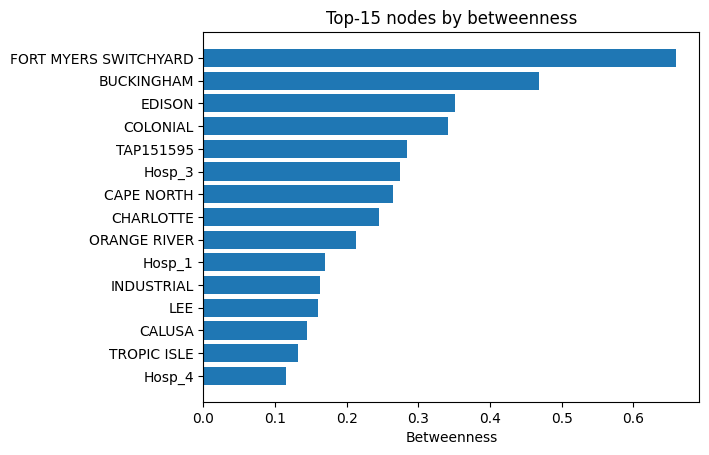

In [334]:
import matplotlib.pyplot as plt

top = nodes_df.sort_values("betweenness", ascending=False).head(15)
plt.figure()
plt.barh(top["node"].astype(str), top["betweenness"])
plt.xlabel("Betweenness")
plt.title("Top-15 nodes by betweenness")
plt.gca().invert_yaxis()
plt.show()


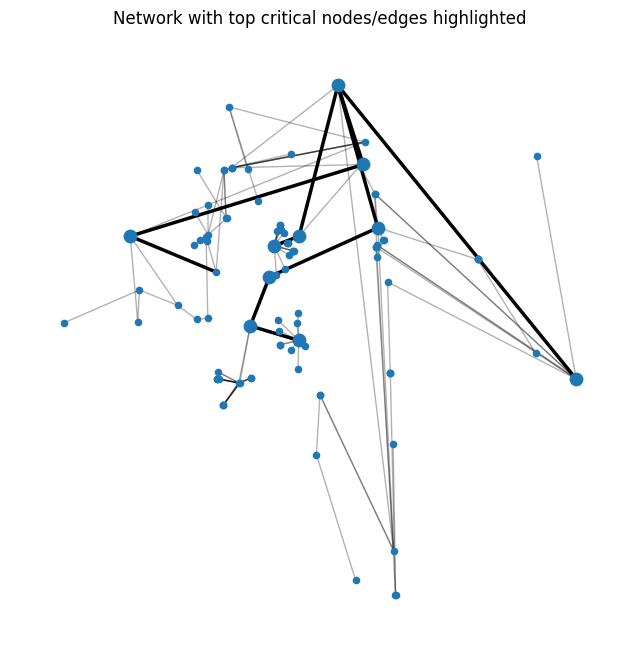

In [335]:
import matplotlib.pyplot as plt
import networkx as nx

pos = pos  # your dict: node -> (x, y)

top_nodes = set(nodes_df.sort_values("betweenness", ascending=False).head(10)["node"])
top_edges = set(tuple(x) for x in edges_df.sort_values("edge_betweenness", ascending=False).head(10)[["u","v"]].to_numpy())

plt.figure(figsize=(8,8))
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=list(top_nodes), node_size=80)
nx.draw_networkx_edges(G, pos, edgelist=list(top_edges), width=2.5)
plt.title("Network with top critical nodes/edges highlighted")
plt.axis("off")
plt.show()


## Subgraph

In [342]:
def subgraph_by_etype(G, keep_prefix):
    edges = [(u,v) for u,v,d in G.edges(data=True) if str(d.get("edge_type","")).startswith(keep_prefix)]
    return G.edge_subgraph(edges).copy()

G_power = subgraph_by_etype(G, "power_transmission")
G_power_hosp  = subgraph_by_etype(G, "power_hospital")
G_comm  = subgraph_by_etype(G, "comm_hospital")

layer_summary = pd.DataFrame([
    summarize_graph(G_power, "power_transmission"),
    summarize_graph(G_power_hosp, "power_hospital"),
    summarize_graph(G_comm,  "comm_hospital")
])

layer_summary
# layer_summary.to_csv("layer_summary.csv", index=False)

is not directed
is not directed
is not directed


,name,N_nodes,M_edges,density,n_components,gcc_frac,avg_degree,max_degree,avg_path_len_GCC,diameter_GCC,global_efficiency,avg_clustering
0,power_transmission,57,67,0.041980,1,1.000000,2.350877,8,4.807644,10,0.268615,0.064453
1,power_hospital,8,5,0.178571,3,0.500000,1.250000,3,1.500000,2,0.232143,0.000000
2,comm_hospital,44,48,0.050740,4,0.363636,2.181818,15,1.875000,2,0.152748,0.000000


## Hospital-focused (TBC)

# hospitals found: 5

=== Hospital Baseline Connectivity Summary ===

Power provider redundancy (counts):
power_redundancy
1 (single)    5

Comm provider redundancy (counts):
comm_redundancy
2+ (redundant)    5

GCC membership (fraction of hospitals):
in_GCC_integrated: 1.000
in_GCC_power: 1.000
in_GCC_comm: 0.200

Provider count stats:
       n_power_providers  n_comm_providers
count                5.0             5.000
mean                 1.0             9.600
std                  0.0             3.286
min                  1.0             6.000
25%                  1.0             9.000
50%                  1.0             9.000
75%                  1.0             9.000
max                  1.0            15.000

Hospitals with NO power providers:
Empty DataFrame
Columns: [hospital, deg_integrated, deg_power_edges]
Index: []

Hospitals with NO comm providers:
Empty DataFrame
Columns: [hospital, deg_integrated, deg_comm_edges]
Index: []

Saved: hospital_baseline_metrics.csv


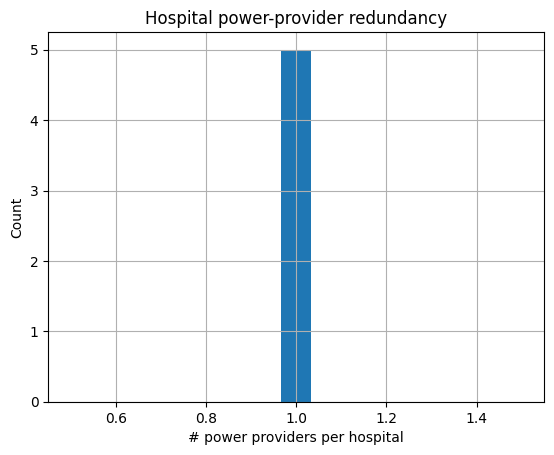

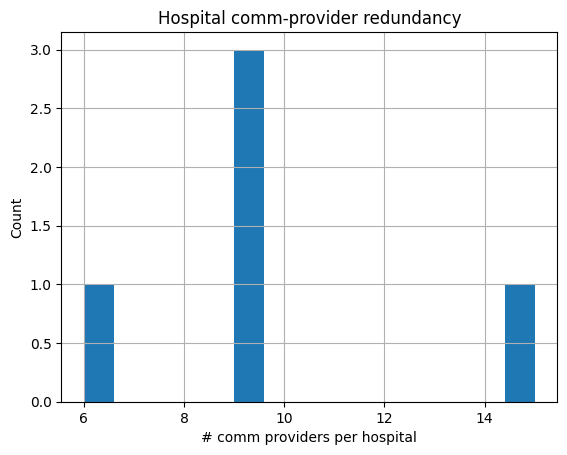

In [343]:
import networkx as nx
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ----------------------------
# User-configurable keys/labels
# ----------------------------
NODE_TYPE_KEY = "type"          # e.g., "type" or "ntype"
HOSPITAL_LABELS = {"hospitals"} # change to {"hospital"} if needed
EDGE_TYPE_KEY = "edge_type"     # e.g., "edge_type" or "etype"

# Define what counts as "power provider" vs "comm provider" by NODE type.
# Adjust these to match your node taxonomy.
POWER_PROVIDER_NODETYPES = {"substations", "plants", "substation", "plant"}
COMM_PROVIDER_NODETYPES  = {"comm_towers", "tower", "comm_tower", "commtower"}

# Define what counts as power vs comm by EDGE type string matching.
# Adjust to your encoding (e.g. "138 kV", "230 kV", etc.)
def is_power_edge(ed):
    return "kV" in str(ed.get(EDGE_TYPE_KEY, "")) or "power" in str(ed.get(EDGE_TYPE_KEY, "")).lower()

def is_comm_edge(ed):
    s = str(ed.get(EDGE_TYPE_KEY, "")).lower()
    return "comm" in s

# ----------------------------
# Helpers
# ----------------------------
def get_hospitals(G):
    return [n for n, d in G.nodes(data=True) if d.get(NODE_TYPE_KEY) in HOSPITAL_LABELS]

def gcc_nodes(G):
    """Return node set of GCC (weakly connected if directed)."""
    if G.number_of_nodes() == 0:
        return set()
    if G.is_directed():
        comps = list(nx.weakly_connected_components(G))
    else:
        comps = list(nx.connected_components(G))
    return max(comps, key=len) if comps else set()

def subgraph_by_edge_filter(G, edge_keep_fn):
    edges = [(u, v) for u, v, d in G.edges(data=True) if edge_keep_fn(d)]
    return G.edge_subgraph(edges).copy()

# Build layer-ish subgraphs from the same node set (edges filtered)
G_power = subgraph_by_edge_filter(G, is_power_edge)
G_comm  = subgraph_by_edge_filter(G, is_comm_edge)

# GCC sets for membership flags
gcc_integrated = set(gcc_nodes(G.to_undirected()))
gcc_power      = set(gcc_nodes(G_power.to_undirected()))
gcc_comm       = set(gcc_nodes(G_comm.to_undirected()))

hospitals = get_hospitals(G)
print(f"# hospitals found: {len(hospitals)}")

# ----------------------------
# Compute baseline hospital metrics
# ----------------------------
rows = []
for h in hospitals:
    # Integrated neighbors
    neigh = set(G.neighbors(h)) if not G.is_directed() else set(G.to_undirected().neighbors(h))

    # Provider neighbors by NODE type
    power_providers_by_node = {j for j in neigh if G.nodes[j].get(NODE_TYPE_KEY) in POWER_PROVIDER_NODETYPES}
    comm_providers_by_node  = {j for j in neigh if G.nodes[j].get(NODE_TYPE_KEY) in COMM_PROVIDER_NODETYPES}

    # Provider neighbors by EDGE type (more robust when node typing is imperfect)
    power_providers_by_edge = set()
    comm_providers_by_edge  = set()

    for j in neigh:
        # Look for ANY edge between h and j that matches power/comm definition
        # Works for simple Graph/DiGraph. If MultiGraph, see note below.
        ed = G.get_edge_data(h, j, default={}) or G.get_edge_data(j, h, default={}) or {}
        # In a MultiGraph, ed is a dict-of-dicts; handle that case:
        if G.is_multigraph():
            for _, attr in ed.items():
                if is_power_edge(attr):
                    power_providers_by_edge.add(j)
                if is_comm_edge(attr):
                    comm_providers_by_edge.add(j)
        else:
            if is_power_edge(ed):
                power_providers_by_edge.add(j)
            if is_comm_edge(ed):
                comm_providers_by_edge.add(j)

    # Degrees
    deg_integrated = G.degree(h)
    deg_power = G_power.degree(h) if h in G_power else 0
    deg_comm  = G_comm.degree(h) if h in G_comm else 0

    # Provider counts (take union of node-type and edge-type approaches)
    power_providers = power_providers_by_node.union(power_providers_by_edge)
    comm_providers  = comm_providers_by_node.union(comm_providers_by_edge)

    rows.append({
        "hospital": h,
        "deg_integrated": deg_integrated,
        "deg_power_edges": deg_power,
        "deg_comm_edges": deg_comm,
        "n_power_providers": len(power_providers),
        "n_comm_providers": len(comm_providers),
        "in_GCC_integrated": h in gcc_integrated,
        "in_GCC_power": h in gcc_power,
        "in_GCC_comm": h in gcc_comm,
    })

df_hosp = pd.DataFrame(rows)

# Redundancy classes
def redundancy_class(x):
    if x == 0:
        return "0 (none)"
    if x == 1:
        return "1 (single)"
    return "2+ (redundant)"

df_hosp["power_redundancy"] = df_hosp["n_power_providers"].apply(redundancy_class)
df_hosp["comm_redundancy"]  = df_hosp["n_comm_providers"].apply(redundancy_class)

# ----------------------------
# Print concise baseline summary
# ----------------------------
print("\n=== Hospital Baseline Connectivity Summary ===")

print("\nPower provider redundancy (counts):")
print(df_hosp["power_redundancy"].value_counts().to_string())

print("\nComm provider redundancy (counts):")
print(df_hosp["comm_redundancy"].value_counts().to_string())

print("\nGCC membership (fraction of hospitals):")
for col in ["in_GCC_integrated", "in_GCC_power", "in_GCC_comm"]:
    frac = df_hosp[col].mean() if len(df_hosp) else float("nan")
    print(f"{col}: {frac:.3f}")

print("\nProvider count stats:")
print(df_hosp[["n_power_providers","n_comm_providers"]].describe().round(3).to_string())

# Optional: list most vulnerable hospitals (no providers)
print("\nHospitals with NO power providers:")
print(df_hosp.loc[df_hosp["n_power_providers"] == 0, ["hospital","deg_integrated","deg_power_edges"]].to_string(index=False))

print("\nHospitals with NO comm providers:")
print(df_hosp.loc[df_hosp["n_comm_providers"] == 0, ["hospital","deg_integrated","deg_comm_edges"]].to_string(index=False))

# ----------------------------
# Save hospital-level table
# ----------------------------
df_hosp.to_csv("hospital_baseline_metrics.csv", index=False)
print("\nSaved: hospital_baseline_metrics.csv")

# ----------------------------
# Optional plots (simple, publication-friendly)
# ----------------------------
plt.figure()
df_hosp["n_power_providers"].hist(bins=15)
plt.xlabel("# power providers per hospital")
plt.ylabel("Count")
plt.title("Hospital power-provider redundancy")
plt.show()

plt.figure()
df_hosp["n_comm_providers"].hist(bins=15)
plt.xlabel("# comm providers per hospital")
plt.ylabel("Count")
plt.title("Hospital comm-provider redundancy")
plt.show()


# Targeted attack - 1 substations

--- Step-by-Step Cascading Failure Simulation ---
Identified 3 Power Sources.
Targeting Node: FORT MYERS SWITCHYARD (Degree: 8)


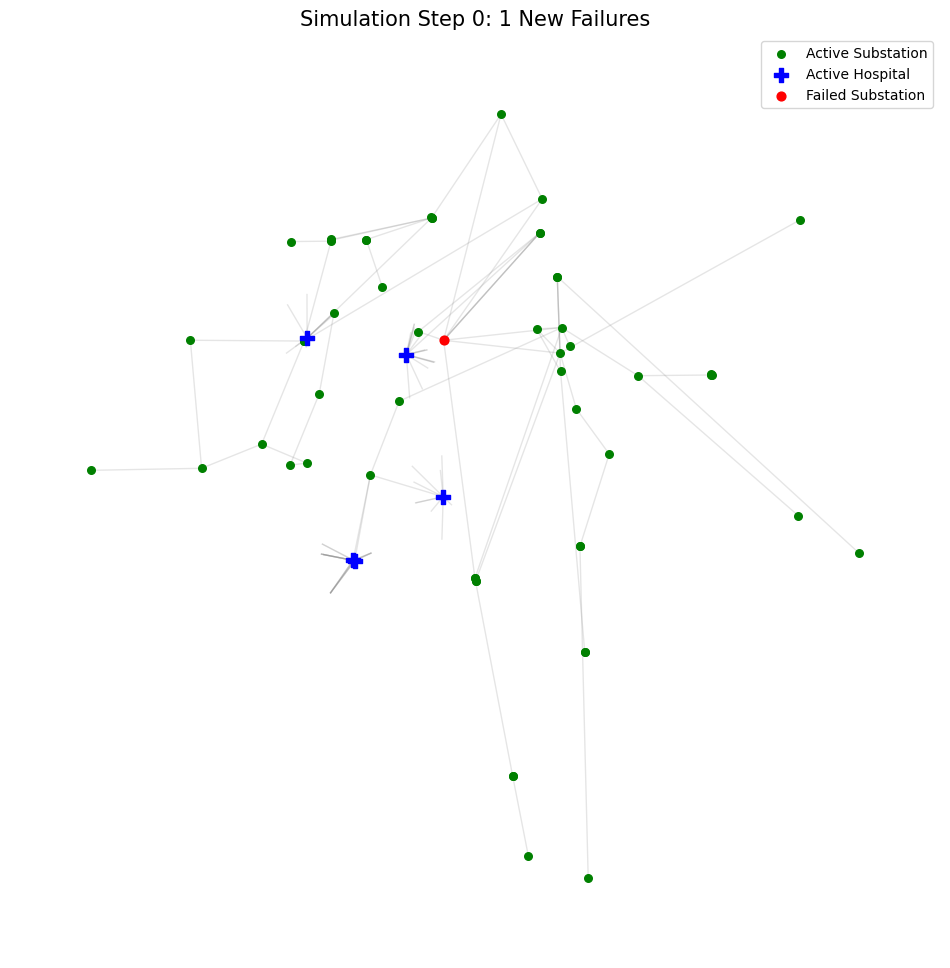

Step 1: 4 nodes failed.


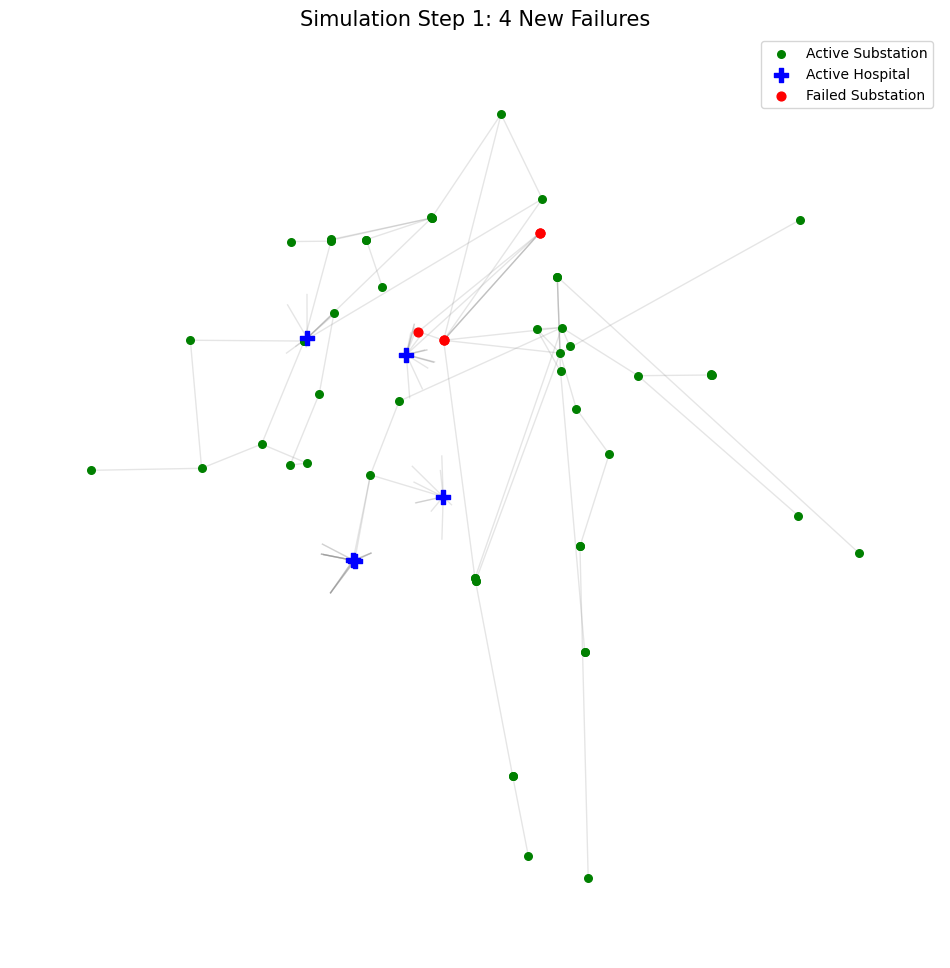

Step 2: 1 nodes failed.


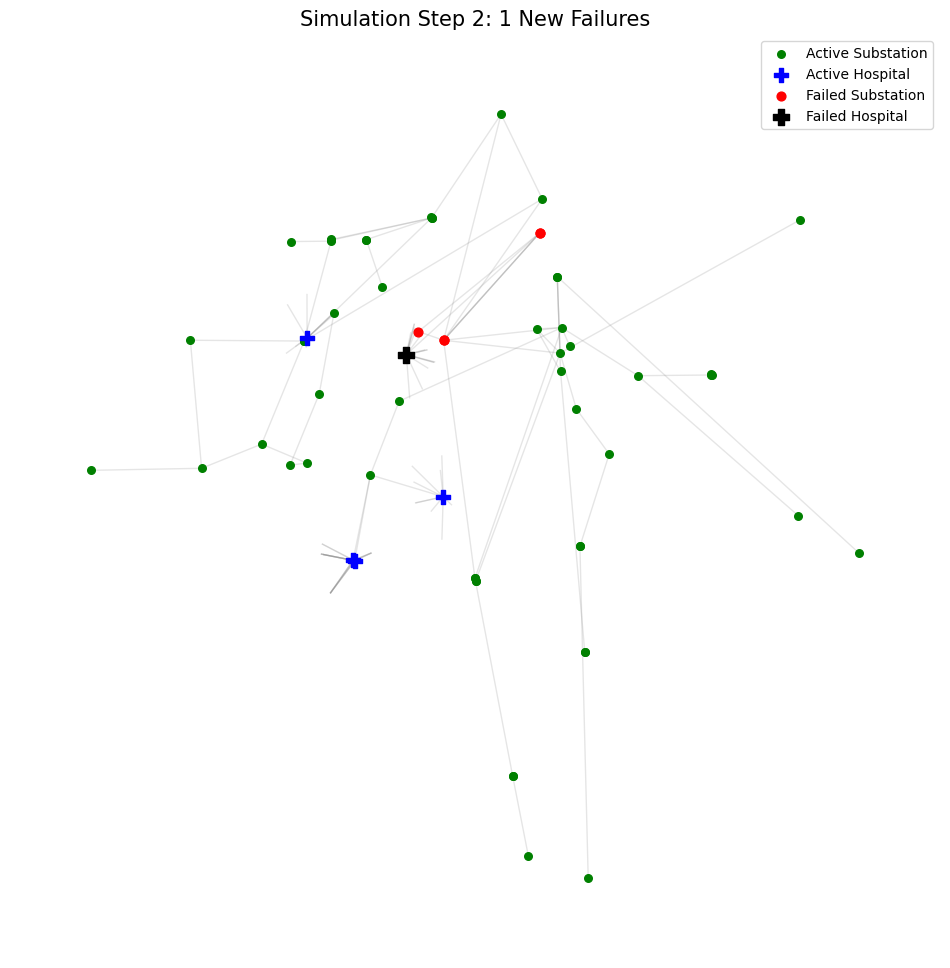

Simulation Stabilized. No new failures.
------------------------------
Impact Analysis:
Total Hospitals: 5
Failed Hospitals: 1
Survival Rate: 80.0%


In [844]:
print("--- Step-by-Step Cascading Failure Simulation ---")

# ==========================================
# 1. Setup & Initialization
# ==========================================
# Create a copy so we don't mess up the original graph
G_sim = G.copy()

# Initialize all nodes as 'Active'
nx.set_node_attributes(G_sim, 'Active', 'status')

# Identify Power Sources (The roots of the grid)
# Logic: Nodes with 500kV are sources. If none, pick top 3 high-degree nodes.
power_sources = [n for n, d in G_sim.nodes(data=True) if d.get('VOLTAGE') == 500]

if not power_sources:
    # Fallback: Top 3 connected nodes
    power_nodes = [n for n, d in G_sim.nodes(data=True) if d.get('type') == 'power']
    power_sources = sorted(power_nodes, key=lambda n: G_sim.degree(n), reverse=True)[:3]

print(f"Identified {len(power_sources)} Power Sources.")

# ==========================================
# 2. Define Visualization Function
# ==========================================
def plot_simulation_step(graph, step_num, new_failures_count):
    plt.figure(figsize=(12, 12))
    
    # --- Filter Nodes by Status & Type ---
    # Active
    active_power = [n for n, d in graph.nodes(data=True) if d['status'] == 'Active' and d.get('type') == 'power']
    active_hosp = [n for n, d in graph.nodes(data=True) if d['status'] == 'Active' and d.get('type') == 'hospital']
    
    # Failed
    failed_power = [n for n, d in graph.nodes(data=True) if d['status'] == 'Failed' and d.get('type') == 'power']
    failed_hosp = [n for n, d in graph.nodes(data=True) if d['status'] == 'Failed' and d.get('type') == 'hospital']

    # --- Plotting ---
    # 1. Active Power (Green Circles)
    nx.draw_networkx_nodes(graph, pos, nodelist=active_power, node_size=30, node_color='green', label='Active Substation')
    
    # 2. Active Hospitals (Blue Plus)
    nx.draw_networkx_nodes(graph, pos, nodelist=active_hosp, node_size=100, node_color='blue', node_shape='P', label='Active Hospital')
    
    # 3. Failed Power (Red Circles)
    if failed_power:
        nx.draw_networkx_nodes(graph, pos, nodelist=failed_power, node_size=40, node_color='red', label='Failed Substation')
        
    # 4. Failed Hospitals (Black Plus)
    if failed_hosp:
        nx.draw_networkx_nodes(graph, pos, nodelist=failed_hosp, node_size=120, node_color='black', node_shape='P', label='Failed Hospital')

    # 5. Edges (Faint)
    nx.draw_networkx_edges(graph, pos, alpha=0.2, edge_color='gray')

    plt.title(f"Simulation Step {step_num}: {new_failures_count} New Failures", fontsize=15)
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()

# ==========================================
# 3. Trigger the Attack (Step 0)
# ==========================================
# Find the highest degree power node
power_nodes = [n for n, d in G_sim.nodes(data=True) if d.get('type') == 'power']
target_node = max(power_nodes, key=lambda n: G_sim.degree(n))

print(f"Targeting Node: {target_node} (Degree: {G_sim.degree(target_node)})")

# Execute Attack
G_sim.nodes[target_node]['status'] = 'Failed'

# Visualize Step 0
plot_simulation_step(G_sim, step_num=0, new_failures_count=1)

# ==========================================
# 4. Run Cascade Loop
# ==========================================
step = 1

while True:
    newly_failed = []
    
    # Get list of currently active nodes
    active_nodes = [n for n, d in G_sim.nodes(data=True) if d['status'] == 'Active']
    
    # Create a subgraph of active nodes to check connectivity
    # (Dead nodes are removed from this temporary graph)
    G_active_subgraph = G_sim.subgraph(active_nodes)
    
    for n in active_nodes:
        node_type = G_sim.nodes[n].get('type')
        
        # --- Logic A: Power Substations ---
        if node_type == 'power':
            # Rule: Must have a path to AT LEAST ONE active Source
            connected_to_source = False
            
            # Optimization: If the node is a source itself, it is safe
            if n in power_sources:
                connected_to_source = True
            else:
                for source in power_sources:
                    # Source must be active and reachable
                    if source in G_active_subgraph and nx.has_path(G_active_subgraph, source, n):
                        connected_to_source = True
                        break
            
            if not connected_to_source:
                newly_failed.append(n)

        # --- Logic B: Hospitals ---
        elif node_type == 'hospital':
            # Rule: Must be connected to at least one ACTIVE substation
            neighbors = list(G_sim.neighbors(n))
            has_active_power = False
            
            for nb in neighbors:
                # Check if neighbor is Power type AND Active
                if G_sim.nodes[nb].get('type') == 'power' and G_sim.nodes[nb]['status'] == 'Active':
                    has_active_power = True
                    break
            
            if not has_active_power:
                newly_failed.append(n)
    
    # --- Update Status ---
    if len(newly_failed) == 0:
        print("Simulation Stabilized. No new failures.")
        break
        
    print(f"Step {step}: {len(newly_failed)} nodes failed.")
    
    for n in newly_failed:
        G_sim.nodes[n]['status'] = 'Failed'
        
    # --- Visualize This Step ---
    plot_simulation_step(G_sim, step_num=step, new_failures_count=len(newly_failed))
    
    step += 1

# ==========================================
# 5. Final Report
# ==========================================
total_hospitals = len([n for n, d in G_sim.nodes(data=True) if d.get('type') == 'hospital'])
failed_hospitals = len([n for n, d in G_sim.nodes(data=True) if d.get('type') == 'hospital' and d['status'] == 'Failed'])

print("-" * 30)
print(f"Impact Analysis:")
print(f"Total Hospitals: {total_hospitals}")
print(f"Failed Hospitals: {failed_hospitals}")
print(f"Survival Rate: {(1 - failed_hospitals/total_hospitals)*100:.1f}%")

# Targeted attack - 1 zone

In [848]:
print("--- Simulation: Spatial Buffer Attack (Power + Comm + Hospital) ---")

# 1. Setup Simulation Graph
G_sim = G.copy()
nx.set_node_attributes(G_sim, 'Active', 'status')

# 2. Define Attack Parameters
# Find the highest degree power node to target
power_nodes = [n for n, d in G_sim.nodes(data=True) if d.get('type') == 'power']
target_node = max(power_nodes, key=lambda n: G_sim.degree(n))

# Define Buffer Radius (e.g., 2 miles = ~3218 meters)
attack_radius = 8000 

# Create the Polygon for the attack zone
target_coords = pos[target_node] # (x, y)
attack_zone = Point(target_coords).buffer(attack_radius)

print(f"Target: {target_node}")
print(f"Attack Zone Radius: {attack_radius} meters")

# 3. Execute Physical Attack (Step 0)
# Find ALL nodes inside the zone
physically_destroyed = []

for n in G_sim.nodes:
    if n in pos:
        node_pt = Point(pos[n])
        if node_pt.within(attack_zone):
            G_sim.nodes[n]['status'] = 'Failed'
            physically_destroyed.append(n)

print(f"Step 0 Impact: {len(physically_destroyed)} nodes destroyed physically.")

--- Simulation: Spatial Buffer Attack (Power + Comm + Hospital) ---
Target: FORT MYERS SWITCHYARD
Attack Zone Radius: 8000 meters
Step 0 Impact: 55 nodes destroyed physically.


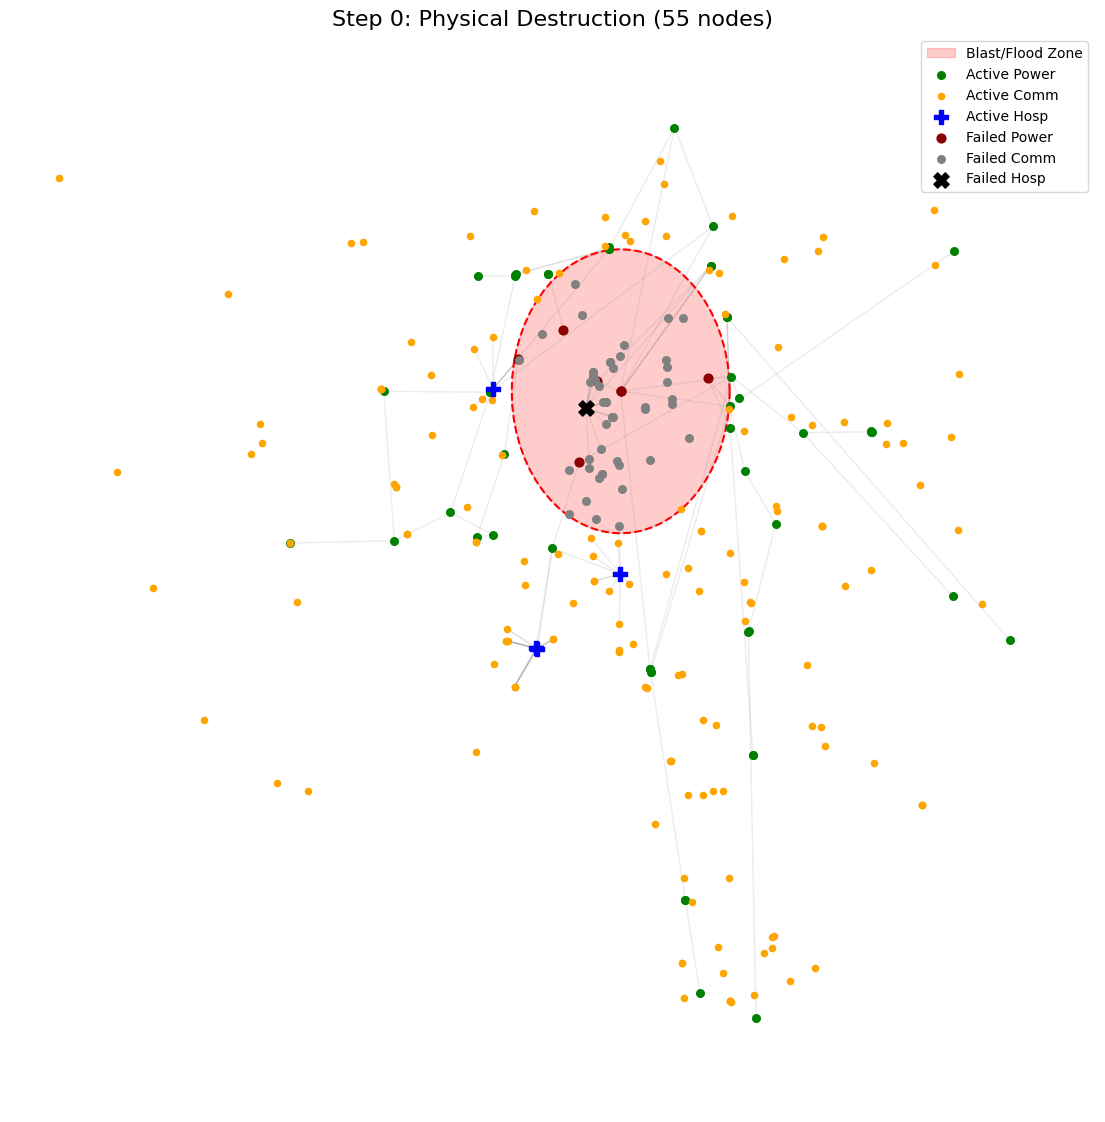

In [849]:
def plot_attack_step(graph, step_num, title_text, zone_poly):
    plt.figure(figsize=(14, 14))
    
    # --- 1. Separate Nodes by Type & Status ---
    # Active Groups
    act_p = [n for n, d in graph.nodes(data=True) if d['status'] == 'Active' and d.get('type') == 'power']
    act_h = [n for n, d in graph.nodes(data=True) if d['status'] == 'Active' and d.get('type') == 'hospital']
    act_c = [n for n, d in graph.nodes(data=True) if d['status'] == 'Active' and d.get('type') == 'communication']
    
    # Failed Groups
    fail_p = [n for n, d in graph.nodes(data=True) if d['status'] == 'Failed' and d.get('type') == 'power']
    fail_h = [n for n, d in graph.nodes(data=True) if d['status'] == 'Failed' and d.get('type') == 'hospital']
    fail_c = [n for n, d in graph.nodes(data=True) if d['status'] == 'Failed' and d.get('type') == 'communication']

    # --- 2. Plotting ---
    
    # Draw Attack Zone (Transparent Red Circle)
    if zone_poly:
        x, y = zone_poly.exterior.xy
        plt.fill(x, y, color='red', alpha=0.2, label='Blast/Flood Zone')
        plt.plot(x, y, color='red', linestyle='--')

    # Draw Edges (Faint)
    nx.draw_networkx_edges(graph, pos, alpha=0.15, edge_color='gray')

    # Draw Nodes (Active)
    nx.draw_networkx_nodes(graph, pos, nodelist=act_p, node_size=30, node_color='green', label='Active Power')
    nx.draw_networkx_nodes(graph, pos, nodelist=act_c, node_size=20, node_color='orange', label='Active Comm')
    nx.draw_networkx_nodes(graph, pos, nodelist=act_h, node_size=100, node_color='blue', node_shape='P', label='Active Hosp')

    # Draw Nodes (Failed)
    if fail_p: nx.draw_networkx_nodes(graph, pos, nodelist=fail_p, node_size=40, node_color='darkred', label='Failed Power')
    if fail_c: nx.draw_networkx_nodes(graph, pos, nodelist=fail_c, node_size=30, node_color='gray', label='Failed Comm')
    if fail_h: nx.draw_networkx_nodes(graph, pos, nodelist=fail_h, node_size=120, node_color='black', node_shape='X', label='Failed Hosp')

    plt.title(title_text, fontsize=16)
    plt.legend(loc='upper right', fontsize=10)
    plt.axis('off')
    plt.show()

# Visualize Initial Impact
plot_attack_step(G_sim, 0, f"Step 0: Physical Destruction ({len(physically_destroyed)} nodes)", attack_zone)

Step 1: 3 new nodes failed via cascade.


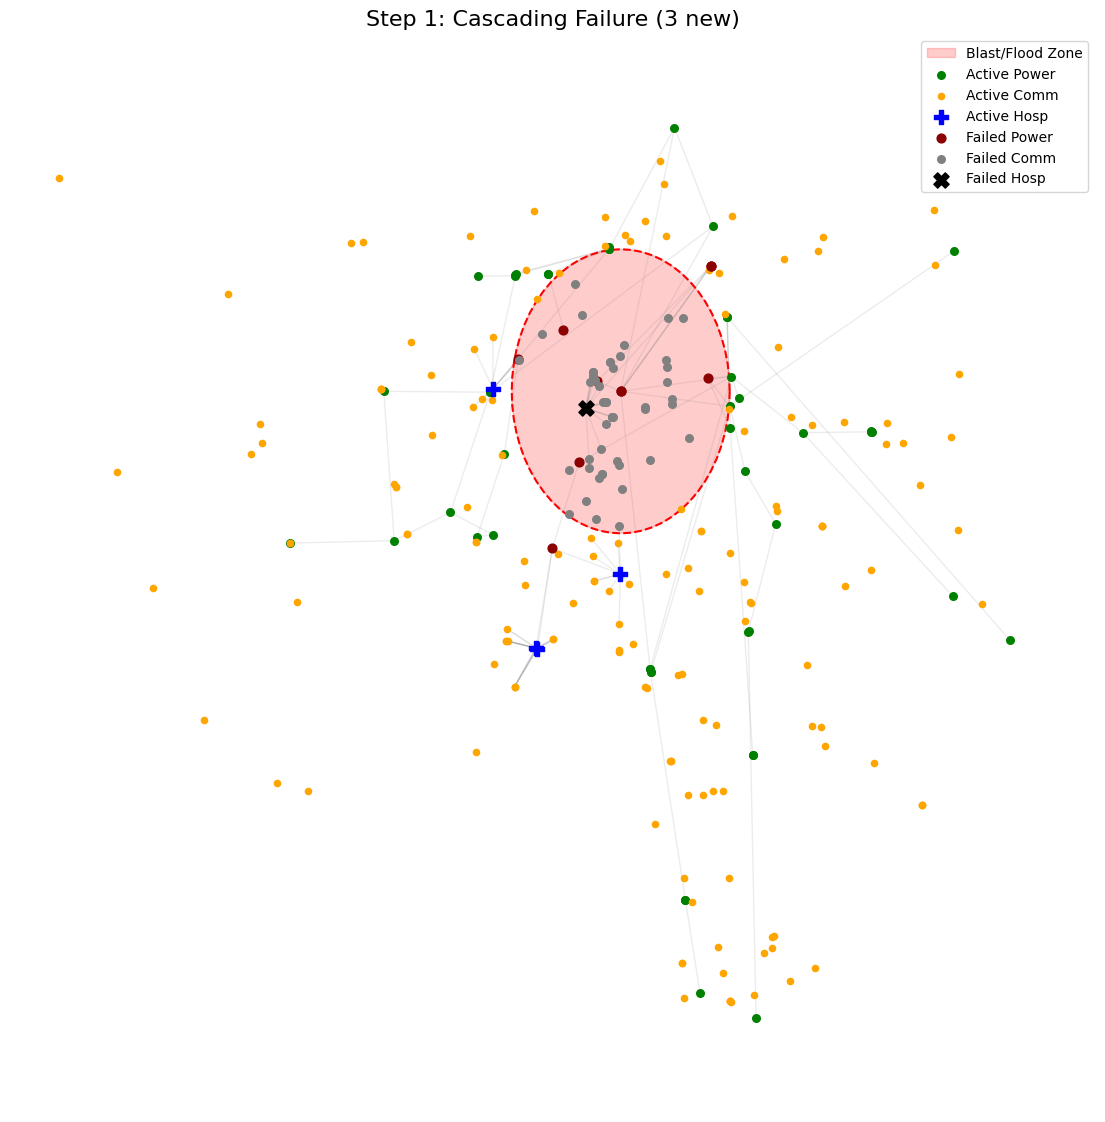

Step 2: 3 new nodes failed via cascade.


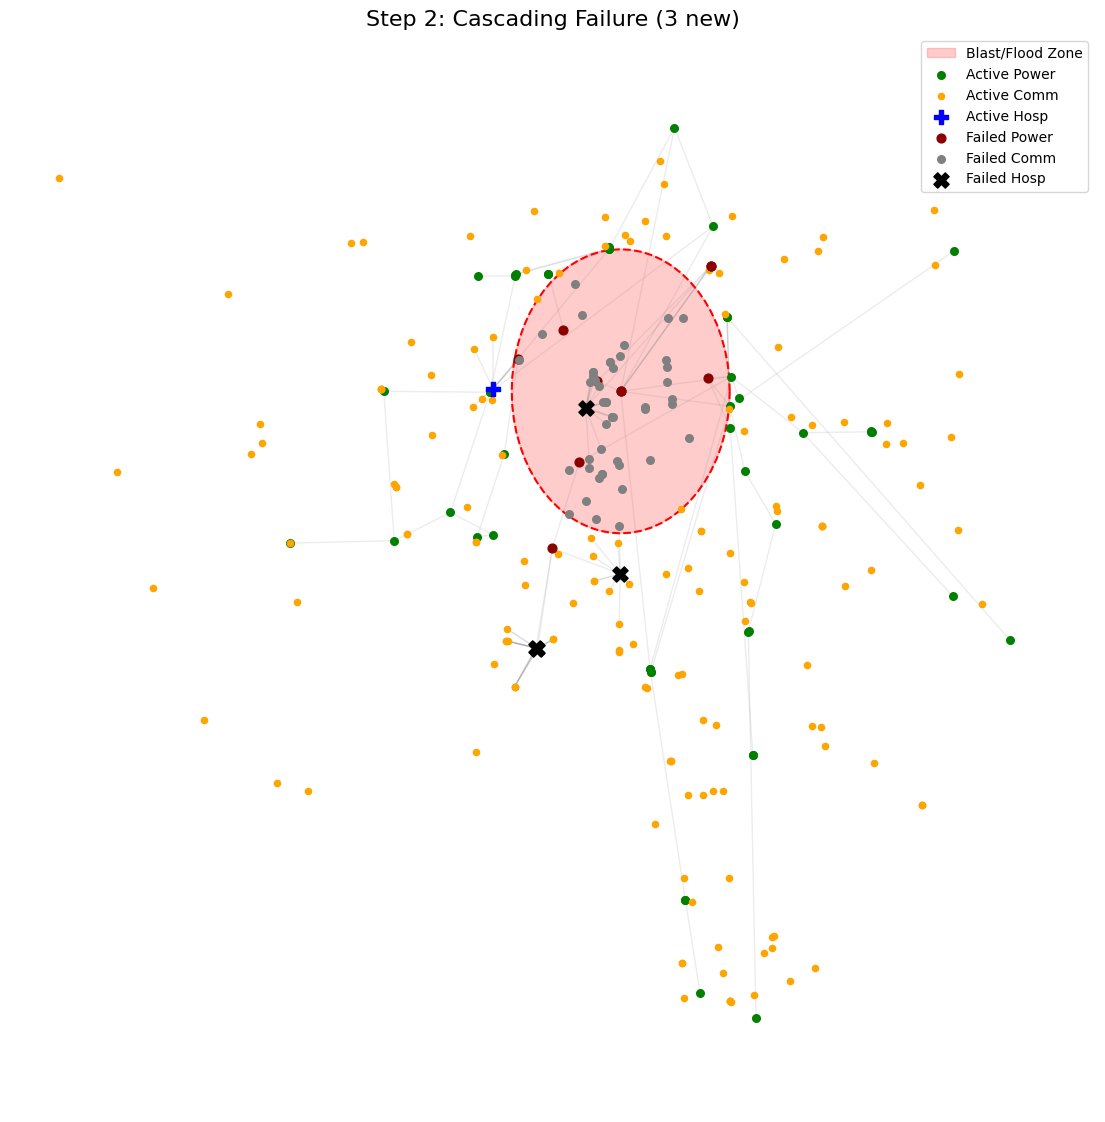

Simulation Stabilized.


In [850]:
# Identify Grid Sources (Highest Voltage)
power_sources = [n for n, d in G_sim.nodes(data=True) if d.get('VOLTAGE') == 500]
if not power_sources:
    # Fallback if no 500kV
    p_nodes = [n for n, d in G_sim.nodes(data=True) if d.get('type') == 'power']
    power_sources = sorted(p_nodes, key=lambda n: G_sim.degree(n), reverse=True)[:3]

step = 1
while True:
    newly_failed = []
    
    # Snapshot of currently active nodes
    active_nodes = [n for n, d in G_sim.nodes(data=True) if d['status'] == 'Active']
    G_active = G_sim.subgraph(active_nodes)
    
    for n in active_nodes:
        node_type = G_sim.nodes[n].get('type')
        
        # --- Rule 1: Power Substation ---
        # Fails if it loses path to all Main Sources
        if node_type == 'power':
            is_connected = False
            if n in power_sources:
                is_connected = True
            else:
                for source in power_sources:
                    if source in G_active and nx.has_path(G_active, source, n):
                        is_connected = True
                        break
            if not is_connected:
                newly_failed.append(n)

        # --- Rule 2: Hospital (Interdependency) ---
        # Fails if NO active Power neighbor OR NO active Comm neighbor
        elif node_type == 'hospital':
            neighbors = list(G_sim.neighbors(n))
            
            has_power = False
            has_comm = False
            
            for nb in neighbors:
                nb_data = G_sim.nodes[nb]
                if nb_data['status'] == 'Active':
                    if nb_data.get('type') == 'power':
                        has_power = True
                    elif nb_data.get('type') == 'communication':
                        has_comm = True
            
            # STRICT Rule: Needs BOTH Power and Comm to function
            if not (has_power and has_comm):
                newly_failed.append(n)
                
        # --- Rule 3: Communication ---
        # Note: In this graph, Comm towers don't have power lines connected to them yet.
        # So they only fail if physically destroyed (Step 0). 
        # If you want them to fail due to grid loss, we would need to build Power->Comm edges.

    if not newly_failed:
        print("Simulation Stabilized.")
        break
    
    # Apply failures
    print(f"Step {step}: {len(newly_failed)} new nodes failed via cascade.")
    for n in newly_failed:
        G_sim.nodes[n]['status'] = 'Failed'
    
    # Visualize
    plot_attack_step(G_sim, step, f"Step {step}: Cascading Failure ({len(newly_failed)} new)", attack_zone)
    step += 1

# Simulate flood scenarios

In [821]:
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# 1. Initialize all nodes as 'Active'
nx.set_node_attributes(G, 'Active', 'status')

# 2. Identify Power Sources (Crucial for connectivity check)
# Let's assume nodes with "Plant" in their ID or highest voltage are sources.
# If you don't have 'Plant' nodes, we can assume the high-voltage (230/500kV) nodes are roots.
power_sources = []
for n, d in G.nodes(data=True):
    # Logic: If it's a power node, we consider it a potential source if it has high connectivity
    # OR you can manually specify IDs: power_sources = ['SUB_1', 'SUB_5']
    if d.get('type') == 'power' or d.get('type') == 'plant':
        power_sources.append(n)

print(f"Total Nodes: {len(G.nodes)}")
print(f"Potential Power Sources: {len(power_sources)}")

Total Nodes: 267
Potential Power Sources: 57


In [838]:
# 1. Create a Synthetic Flood Zone (e.g., a circle in the middle of your map)
# You can replace this with: flood_gdf = gpd.read_file('flood_map.shp')
all_x = [d['pos'][0] for n, d in G.nodes(data=True) if 'pos' in d]
all_y = [d['pos'][1] for n, d in G.nodes(data=True) if 'pos' in d]
mid_x, mid_y = sum(all_x)/len(all_x), sum(all_y)/len(all_y)

# Create a buffer polygon representing the flood
flood_center = Point(mid_x, mid_y)
flood_zone = flood_center.buffer(3000) # 10km radius flood

# 2. Identify nodes directly hit by flood (Physical Failure)
flooded_nodes = []
for n, d in G.nodes(data=True):
    if 'pos' in d:
        node_point = Point(d['pos'])
        if node_point.within(flood_zone):
            flooded_nodes.append(n)
            G.nodes[n]['status'] = 'Failed' # Direct failure

print(f"Nodes directly flooded: {len(flooded_nodes)}")

Nodes directly flooded: 4


In [839]:
def run_cascade_step(G, sources):
    """
    Runs one step of failure propagation.
    Returns: The number of newly failed nodes.
    """
    newly_failed = []
    
    # Get current state
    active_nodes = [n for n, d in G.nodes(data=True) if d['status'] == 'Active']
    
    # Create a subgraph of ONLY active nodes to test connectivity
    G_active = G.subgraph(active_nodes)
    
    for n in active_nodes:
        node_type = G.nodes[n].get('type')
        
        # --- Logic 1: Power Nodes (Grid Topology) ---
        if node_type == 'power':
            # Check if this node can reach ANY active source
            # We use has_path. Note: This can be slow for huge graphs.
            is_connected = False
            for source in sources:
                if source in G_active and nx.has_path(G_active, source, n):
                    is_connected = True
                    break
            
            if not is_connected:
                newly_failed.append(n)
        
        # --- Logic 2: Hospitals (Dependency) ---
        elif node_type == 'hospital':
            # Check Connections
            # 1. Check Power
            neighbors = list(G.neighbors(n))
            has_active_power = False
            has_active_comm = False
            
            for neighbor in neighbors:
                # Check neighbor status and type
                neighbor_status = G.nodes[neighbor]['status']
                neighbor_type = G.nodes[neighbor].get('type')
                edge_data = G.get_edge_data(n, neighbor) # Check edge type if needed
                
                if neighbor_status == 'Active':
                    if neighbor_type == 'power':
                        has_active_power = True
                    elif neighbor_type == 'communication':
                        has_active_comm = True
            
            # Rule: Must have BOTH Power and Comm (Strict)
            # Change 'and' to 'or' if you want a looser rule
            if not (has_active_power and has_active_comm):
                newly_failed.append(n)
        print(newly_failed)
    # Update status for newly failed nodes
    for n in newly_failed:
        G.nodes[n]['status'] = 'Failed'
        
    return len(newly_failed)

In [840]:
print("--- Starting Cascade Simulation ---")

step = 0
while True:
    print(f"Time Step {step}...")
    n_failures = run_cascade_step(G, power_sources)
    
    if n_failures == 0:
        print("Network Stabilized.")
        break
        
    print(f"  -> New Failures: {n_failures}")
    step += 1

# Calculate Final Stats
total_hospitals = len([n for n, d in G.nodes(data=True) if d['type'] == 'hospital'])
failed_hospitals = len([n for n, d in G.nodes(data=True) if d['type'] == 'hospital' and d['status'] == 'Failed'])

print("-" * 30)
print(f"Simulation Complete.")
print(f"Total Hospitals: {total_hospitals}")
print(f"Functional Hospitals: {total_hospitals - failed_hospitals}")
print(f"Failed Hospitals: {failed_hospitals}")

--- Starting Cascade Simulation ---
Time Step 0...
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
Network Stabilized.
------------------------------
Simulation Complete.
Total Hospitals: 5
Functional Hospitals: 1
Failed Hospitals: 4


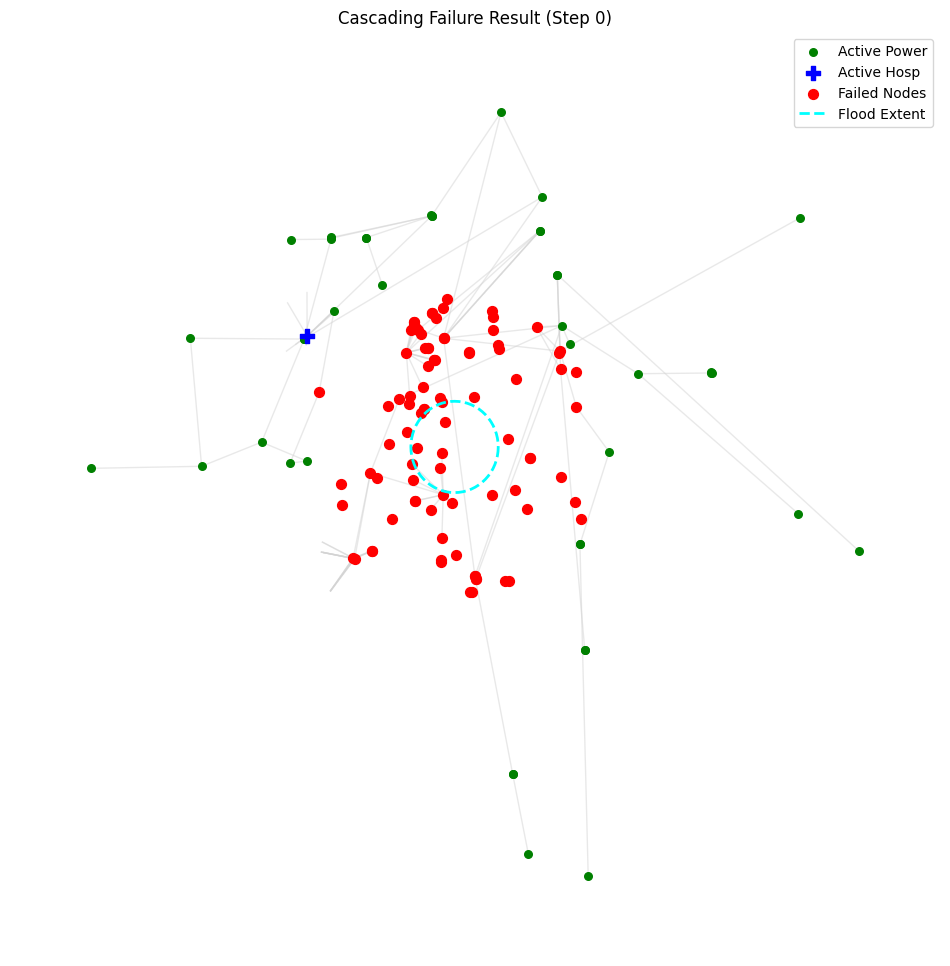

In [841]:
plt.figure(figsize=(12, 12))
pos = nx.get_node_attributes(G, 'pos')

# 1. Draw Edges (Grey background)
nx.draw_networkx_edges(G, pos, edge_color='lightgrey', alpha=0.5)

# 2. Draw Active Nodes
active_power = [n for n, d in G.nodes(data=True) if d['type'] == 'power' and d['status'] == 'Active']
active_hosp = [n for n, d in G.nodes(data=True) if d['type'] == 'hospital' and d['status'] == 'Active']

nx.draw_networkx_nodes(G, pos, nodelist=active_power, node_size=30, node_color='green', label='Active Power')
nx.draw_networkx_nodes(G, pos, nodelist=active_hosp, node_size=100, node_color='blue', node_shape='P', label='Active Hosp')

# 3. Draw Failed Nodes (Red)
failed_nodes = [n for n, d in G.nodes(data=True) if d['status'] == 'Failed']
nx.draw_networkx_nodes(G, pos, nodelist=failed_nodes, node_size=50, node_color='red', label='Failed Nodes')

# 4. Draw Flood Zone
x, y = flood_zone.exterior.xy
plt.plot(x, y, color='cyan', linewidth=2, linestyle='--', label='Flood Extent')

plt.title(f"Cascading Failure Result (Step {step})")
plt.legend()
plt.axis('off')
plt.show()